# Encoder tests: the photos against the encoder

Companion to the tests in this folder. In all of them the photos show where the stage
really is, and the encoder counts of the run are compared with that.

| part | test | what moves | photos |
|---|---|---|---|
| 1 - 5 | `24hrstest_can_linear.py`, `24hrstest_can_rotational.py`: 24 h, three runs | to the **calibration slide** and to the **sample** every 10 min | one per visit |
| 6 | `12hrstest_thermal_drift.py`: 12 h, linear encoder | nothing | one every 10 min |
| 7 | `ultra_test_can_linear.py`, `ultra_test_can_rotational.py`: the 24 h test with random X moves between the visits | as in the 24 h test, and 2 .. 5 times to a random place in between | one per visit |

The three runs of the 24 h test (parts 1 - 5), all open loop at 100000 steps/s:

| run | encoder | read on | compensation zone | lost-step events |
|---|---|---|---|---|
| `linear 10-03` | linear (magnetic), 1.95 um per count | GPIO 40 / 41 | 5 counts = 9.75 um | 9 |
| `rotational 10-04` | rotational, 0.25 um per count | before the PCNT fix | 39 counts = 9.75 um | 7 |
| `rotational 10-06` | rotational, 0.25 um per count | GPIO 5 / 6 (commit `2e042b0`) | 5 counts = 1.25 um | **0** |

Between 10-04 and 10-06 the encoder pins were changed and the slave was flashed again,
and both places were taught again (x, y, z).

`dx`, `dy` = the shift of a photo against the first photo of its place / run, in um,
positive = right / down in the photo. For the 24 h test and the ultra test nothing is
correlated here: the shifts are read from `<run>_shift.csv`, so run
`24hrstest_shift.py <run>.csv` first. The photos of the drift test are correlated in
part 6. The encoder counts and the lost-step events come from `<run>.csv`.

1. 24 h: the shift of the photos, with the lost-step events (6 plots)
2. 24 h: `dx` of the three runs in one plot, with the compensation zones (2 plots)
3. 24 h: encoder minus photo: did the encoder see the shift? (2 plots)
4. 24 h, more: what the compensation saw, where the unseen shift comes from, numbers
5. 24 h: lost steps: how often, and where the stage stopped
6. 12 h thermal drift: the shift when nothing moves, against the encoder and the 24 h test
7. ultra test: the cells of parts 1 - 5 for the 24 h test with random moves

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image   # only for the photos of the drift run (part 6)

# all CSVs are in encoder_test_data, in the root of the repo
DATA_DIR = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "encoder_test_data").exists()) / "encoder_test_data"
PLOT_DIR = DATA_DIR / "encoder_test_plots"   # the plots are saved here
PLOT_DIR.mkdir(exist_ok=True)

# The three runs of the 24 h test (parts 1 - 5).
#   csv           written by the test, one row per visit
#   shift_csv     written by 24hrstest_shift.py from the photos, one row per photo
#   um_per_count  the sign turns the counts into the direction of dx: the linear encoder
#                 counts up when the picture moves right, the rotational one counts down
#   zone_um       half width of the compensation zone = comp_counts (header of the csv) x um per count
RUNS = {
    "linear 10-03": dict(
        csv="24hrstest_can_x_20261003_110333.csv",
        shift_csv="24hrstest_can_x_20261003_110333_shift.csv",
        um_per_count=+1.95,
        zone_um=9.75,   # comp_counts=5
        color="#eb6834",
    ),
    "rotational 10-04": dict(
        csv="24hrstest_can_rotational_x_20261004_151450.csv",
        shift_csv="24hrstest_can_rotational_x_20261004_151450_shift.csv",
        um_per_count=-0.25,
        zone_um=9.75,   # comp_counts=39
        color="#4a3aa7",
    ),
    "rotational 10-06": dict(
        csv="24hrstest_can_rotational_x_20261006_135353.csv",
        shift_csv="24hrstest_can_rotational_x_20261006_135353_shift.csv",
        um_per_count=-0.25,
        zone_um=1.25,   # comp_counts=5
        color="#1baf7a",
    ),
}
PLACES = ("calibration slide", "sample")

# The 12 h thermal drift run (part 6): nothing moves, linear encoder.
#   csv        written by the test, one row per sample (every 10 min)
#   shift_csv  the shift of every photo against the first one in px, written by part 6
#   photos     folder of the photos: 0019_<time>.png is the photo of sample 19
#   um_per_px  the drift photos have no ruler in them: 10 um / 83.85 px, the tick period in
#              the first calibration slide photo of the 24 h run of 10-04 (same microscope)
DRIFT = dict(
    csv="12hrstest_thermal_drift_x_20261005_184730.csv",
    shift_csv="12hrstest_thermal_drift_x_20261005_184730_shift.csv",
    photos="12hrstest_thermal_drift_x_20261005_184730_photos",
    um_per_count=+1.95,
    um_per_px=0.1193,
)

# The runs of the ultra test (part 7): the 24 h test with random X moves between the visits.
#   csv, shift_csv, um_per_count, zone_um   as in RUNS
#   walk_csv   written by the test, one row per random move and per way back
ULTRA_RUNS = {
    "ultra linear 10-07": dict(
        csv="ultra_test_can_linear_x_20261007_172512.csv",
        shift_csv="ultra_test_can_linear_x_20261007_172512_shift.csv",
        walk_csv="ultra_test_can_linear_x_20261007_172512_walk.csv",
        um_per_count=+1.95,
        zone_um=7.80,   # comp_counts=4
        color="#eda100",
    ),
    # The run with the rotational encoder, started on 10-08 18:04. Take the "# " away when
    # it is over and 24hrstest_shift.py has written its _shift.csv.
    # "ultra rotational 10-08": dict(
    #     csv="ultra_test_can_rotational_x_20261008_180412.csv",
    #     shift_csv="ultra_test_can_rotational_x_20261008_180412_shift.csv",
    #     walk_csv="ultra_test_can_rotational_x_20261008_180412_walk.csv",
    #     um_per_count=-0.25,
    #     zone_um=1.25,   # comp_counts=5
    #     color="#e87ba4",
    # ),
}

COLOR = {"dx": "#e34948", "dy": "#2a78d6", "lost": "#008300", "zone": "#8a8984", "ink": "#52514e"}
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "savefig.dpi": 150,
    "lines.linewidth": 1.6, "lines.markersize": 5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.7,
    "axes.titlesize": 11, "axes.titlelocation": "left", "legend.frameon": False,
})

## Data

The file names are in `RUNS`, `DRIFT` and `ULTRA_RUNS` in the cell above.

| file | written by | one row per | columns used here |
|---|---|---|---|
| `<run>.csv` | the 24 h test, the ultra test | visit | `time_iso`, `visit`, `place`, `move`, `rawCounts`, `encDriftCounts`, `event`, `xMoveStart`, `xMoveSec`, `lostSteps`, `stallRawCounts`, `walkLost` (ultra) |
| `<run>_shift.csv` | `24hrstest_shift.py` | photo | `hours`, `visit`, `place`, `dx_um`, `dy_um`, `rawCounts`, `compSteps`, `event` |
| `<run>_walk.csv` | the ultra test | random move | `visit`, `move`, `event` |
| `<drift run>.csv` | `12hrstest_thermal_drift.py` | sample (every 10 min) | `sample`, `elapsed_s`, `commanded`, `rawCounts`, `y`, `z` |
| `<drift run>_shift.csv` | part 6 of this notebook | photo | `photo`, `dx_px`, `dy_px`, `corr` |

Every cell below reads the CSVs it needs itself (`usecols` = the columns it takes), so
it runs on its own after the first cell.

`enc` is what the encoder says about the same thing as `dx`: the raw count against the
raw count at the first photo of the place, times um per count.

## 1. Shift of the photos against the first one

One plot per run and place: `dx` (red) and `dy` (blue). The green dashed lines are
the lost-step events of the run, at the start of the move in which the steps were
lost. All events of the run are in both plots, also the ones on the way to the other
place. The y axis is not the same in the six plots.

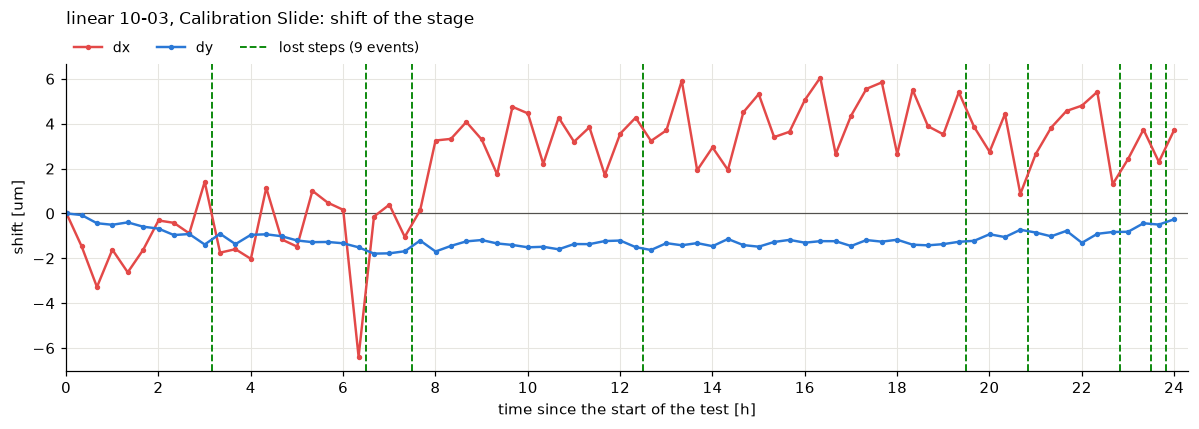

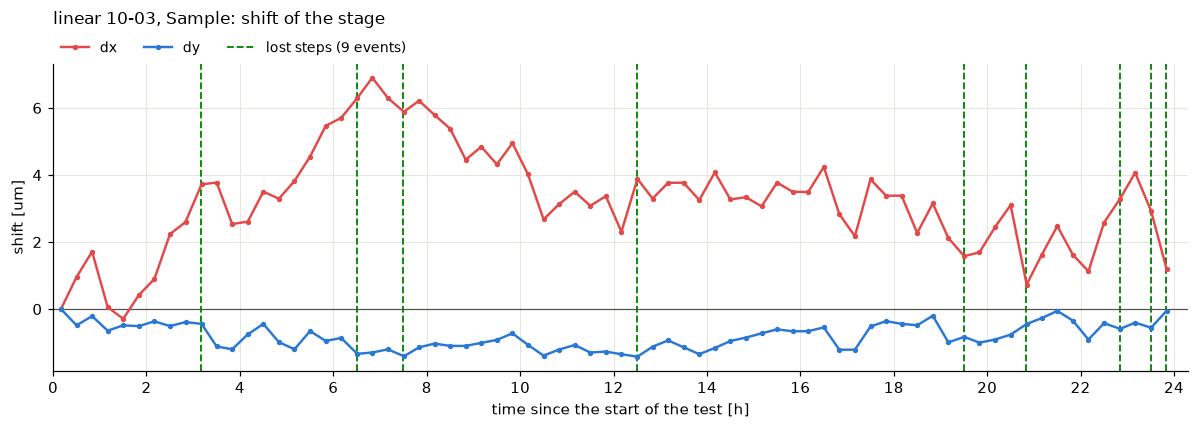

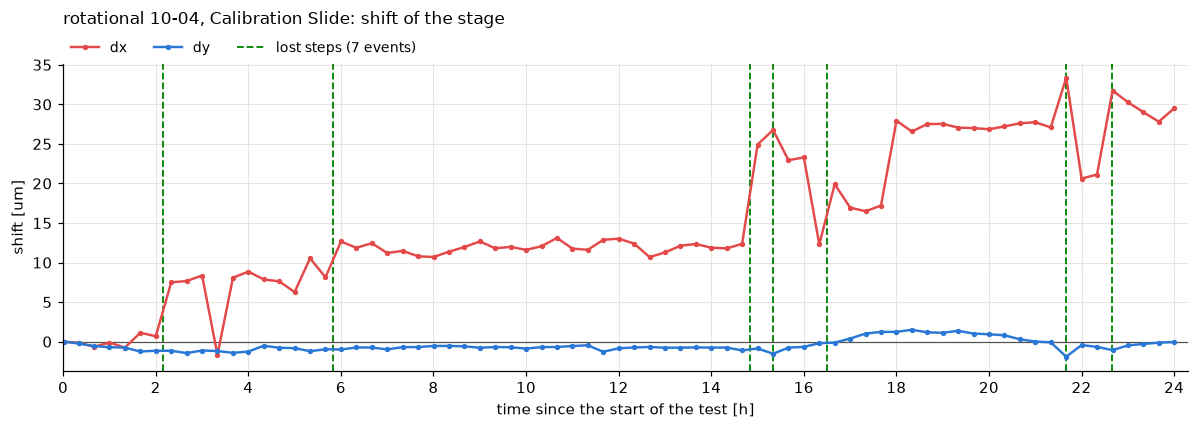

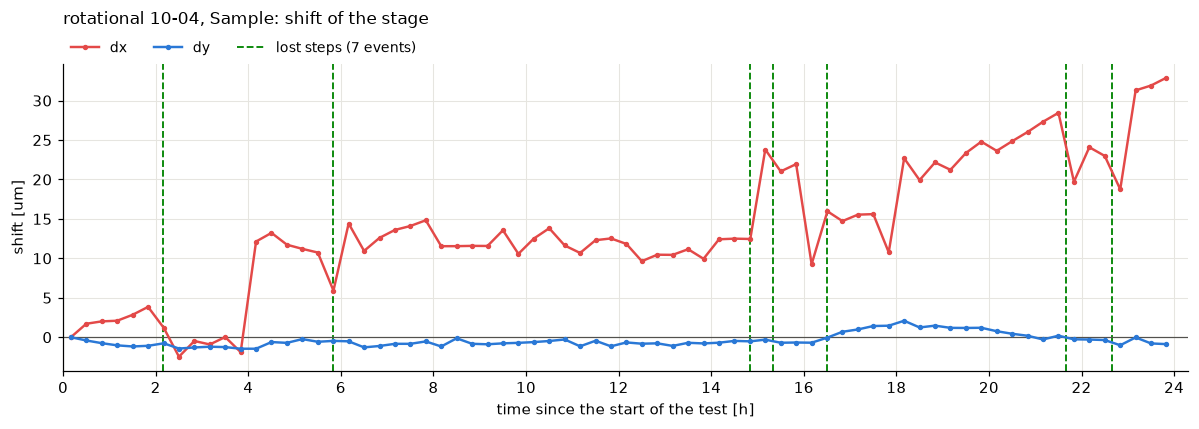

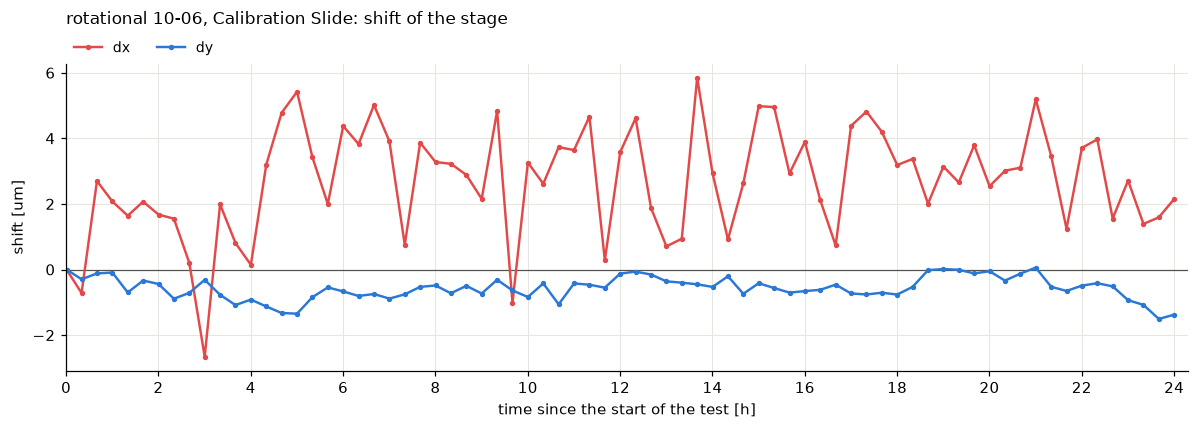

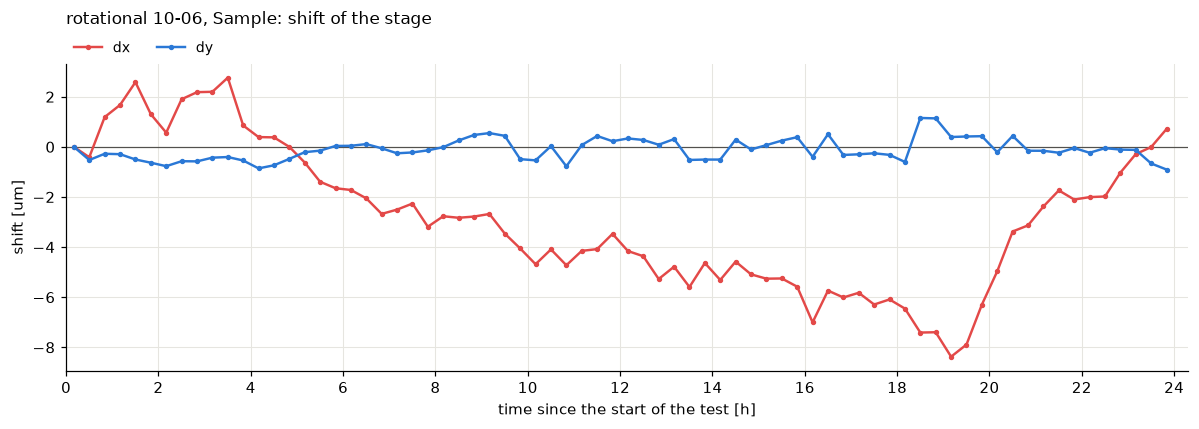

In [2]:
for name, run in RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "dx_um", "dy_um"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move, in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = (lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)

    for place in PLACES:
        photos = shift[shift["place"] == place]

        fig, ax = plt.subplots()
        ax.axhline(0, color=COLOR["ink"], lw=0.8)
        ax.plot(photos["hours"], photos["dx_um"], ".-", color=COLOR["dx"], label="dx")
        ax.plot(photos["hours"], photos["dy_um"], ".-", color=COLOR["dy"], label="dy")
        for i, hours in enumerate(lost_hours):
            ax.axvline(hours, color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                       label=f"lost steps ({len(lost)} events)" if i == 0 else None)

        ax.set_title(f"{name}, {place.title()}: shift of the stage", pad=26)   # pad = room for the legend
        ax.set(ylabel="shift [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
        ax.set_xticks(range(0, 25, 2))
        ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
        fig.tight_layout()
        fig.savefig(PLOT_DIR / f"1_shift_{name}_{place}.png".replace(" ", "_"))
        plt.show()

## 2. dx of the three runs, with the compensation zones

The compensation only corrects X when the encoder is more than `comp_counts` off:
5 counts of the linear encoder (10-03) and 39 counts of the rotational one (10-04) are
both 9.75 um; on 10-06 it was 5 counts of the rotational encoder = 1.25 um. The zones
are drawn around the first photo, like `dx`. The y axis is the same in both plots.

On 10-06 `dx` stays within -8.4 .. +2.8 um at the sample and -2.7 .. +5.9 um at the
calibration slide: about as in the run with the linear encoder (-0.3 .. +6.9 and -6.4 .. +6.1 um)
and without the walk-off of 10-04 (up to +33 um). The picture does leave the
+-1.25 um zone of 10-06, but X was never corrected in that run: the encoder itself
did not leave the zone (see 4.1).

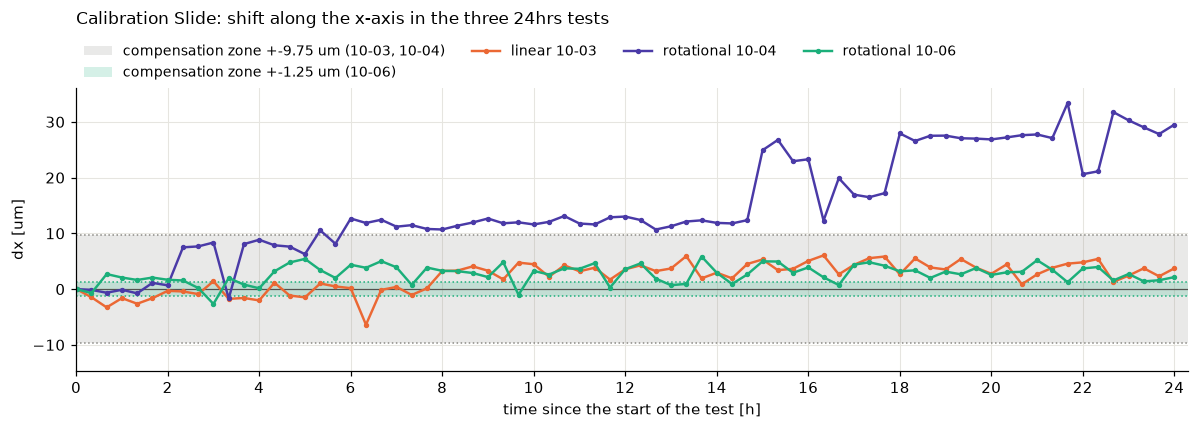

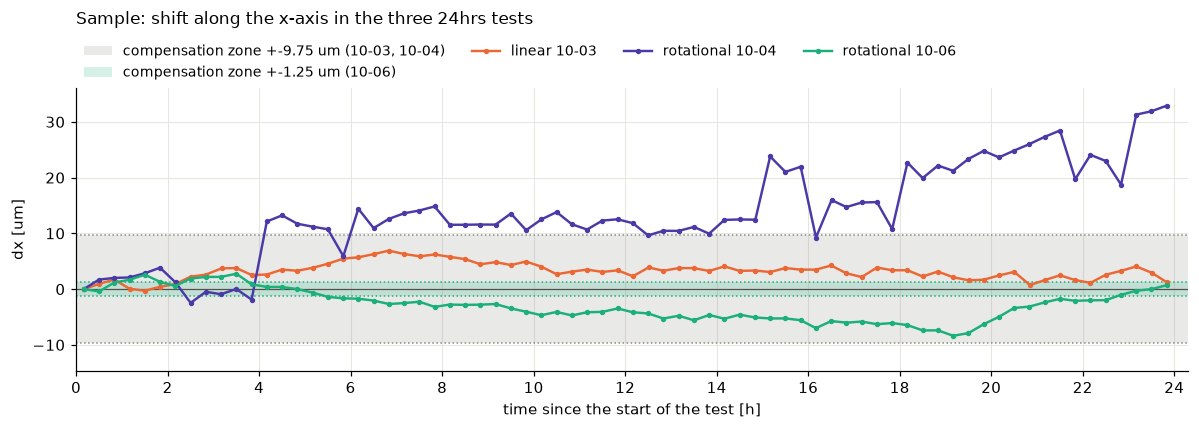

In [3]:
shift = {name: pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "dx_um"])
         for name, run in RUNS.items()}

# compensation zones: 10-03 and 10-04 have the same one, so they share the grey band
zones = [
    (RUNS["linear 10-03"]["zone_um"], COLOR["zone"], "10-03, 10-04"),
    (RUNS["rotational 10-06"]["zone_um"], RUNS["rotational 10-06"]["color"], "10-06"),
]
# the same y axis in both plots: from below the wide zone to just above the largest dx of all runs
y_min = -1.5 * RUNS["linear 10-03"]["zone_um"]
y_max = 1.08 * max(s["dx_um"].abs().max() for s in shift.values())

for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    for um, color, dates in zones:
        ax.axhspan(-um, um, color=color, alpha=0.18, lw=0, label=f"compensation zone +-{um:.2f} um ({dates})")
        ax.axhline(-um, color=color, ls=":", lw=1)
        ax.axhline(+um, color=color, ls=":", lw=1)
    for name, run in RUNS.items():
        photos = shift[name][shift[name]["place"] == place]
        ax.plot(photos["hours"], photos["dx_um"], ".-", color=run["color"], label=name)

    ax.set_title(f"{place.title()}: shift along the x-axis in the three 24hrs tests", pad=42)   # pad = room for the legend
    ax.set(ylabel="dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3), ylim=(y_min, y_max))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"2_dx_{place}.png".replace(" ", "_"))
    plt.show()

## 3. Encoder minus photo: did the encoder see the shift?

`enc - dx`: the raw count against the first photo, times um per count (1.95 um
linear, 0.25 um rotational), minus the shift of the photo. 0 = the encoder reports
exactly what the photo shows; a value that stays away from 0 is a shift of the
picture the encoder does not know about.

The cell below checks the um per count with the photos:
the change of `dx` from one photo to the next against the change of the count. On
10-06 there is nothing to fit: the count is the same at every photo of a place, so
`enc` is 0 and `enc - dx` is just `-dx`. Everything the photos show in that run is a
shift the rotational encoder did not see.

In [4]:
for name, run in RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["place", "rawCounts", "dx_um"])

    # the change of the count and of dx from one photo of a place to the next
    change = shift.groupby("place").diff().dropna()
    d_counts, d_dx = change["rawCounts"], change["dx_um"]

    if (d_counts == 0).all():
        print(f"{name:<17} the count is the same at every photo of a place: nothing to fit, "
              f"dx moves {np.sqrt((d_dx ** 2).mean()):.2f} um rms from photo to photo")
    else:
        moved = d_counts != 0
        fit = (d_counts * d_dx).sum() / (d_counts ** 2).sum()   # slope of the line through 0
        r = np.corrcoef(d_counts[moved], d_dx[moved])[0, 1]
        print(f"{name:<17} count changes up to {d_counts.abs().max():.0f}: dx moves "
              f"{fit:+.2f} um per count (r = {r:+.2f}, used: {run['um_per_count']:+.2f})")

linear 10-03      count changes up to 4: dx moves +0.96 um per count (r = +0.86, used: +1.95)
rotational 10-04  count changes up to 44: dx moves -0.27 um per count (r = -0.89, used: -0.25)
rotational 10-06  the count is the same at every photo of a place: nothing to fit, dx moves 1.54 um rms from photo to photo


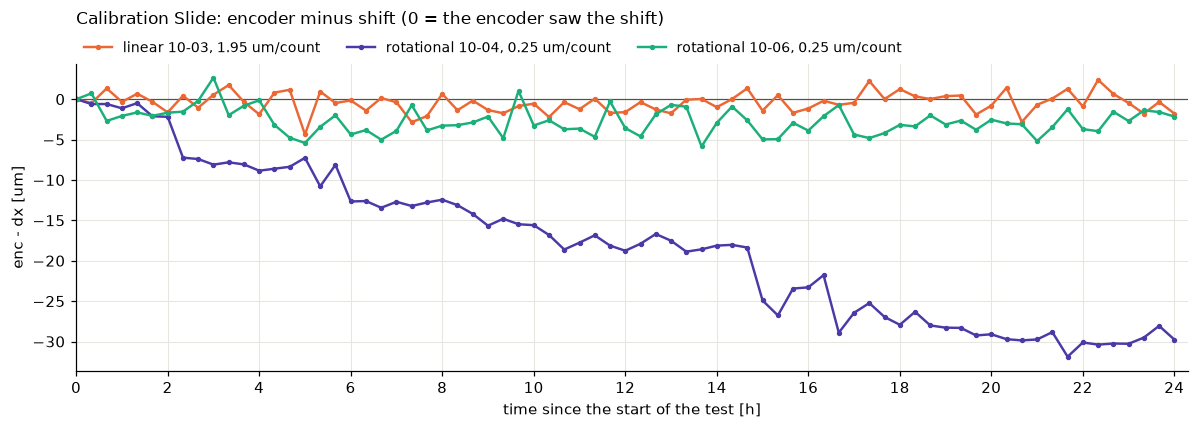

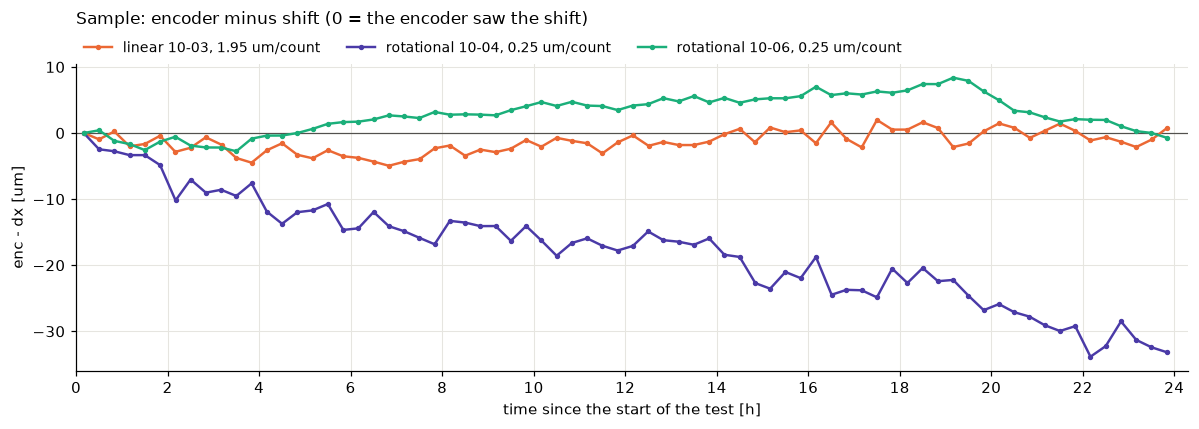

In [5]:
for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    for name, run in RUNS.items():
        shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "rawCounts", "dx_um"])
        photos = shift[shift["place"] == place]
        # enc = the count against the count at the first photo of the place, in um
        enc = (photos["rawCounts"] - photos["rawCounts"].iloc[0]) * run["um_per_count"]
        ax.plot(photos["hours"], enc - photos["dx_um"], ".-", color=run["color"],
                label=f"{name}, {abs(run['um_per_count']):g} um/count")

    ax.set_title(f"{place.title()}: encoder minus shift (0 = the encoder saw the shift)", pad=26)   # pad = room for the legend
    ax.set(ylabel="enc - dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"3_encoder_minus_photo_{place}.png".replace(" ", "_"))
    plt.show()

## 4. More

### 4.1 What the compensation saw

The encoder on arrival, before any correction, against the first arrival at the place
(`encDriftCounts` of the run, in um). This is the number the test compares with the
zone; the circles are the visits where it was outside and X was corrected. The visits
with lost steps are left out (thousands of counts off, they are the green lines of
part 1).

10-06 is a flat line at 0: at all 144 arrivals the count is exactly the count of the
first arrival (0 at the calibration slide, 370087 at the sample). On 10-04 the same encoder was up
to 46 counts off on arrival and X was corrected at 16 visits.

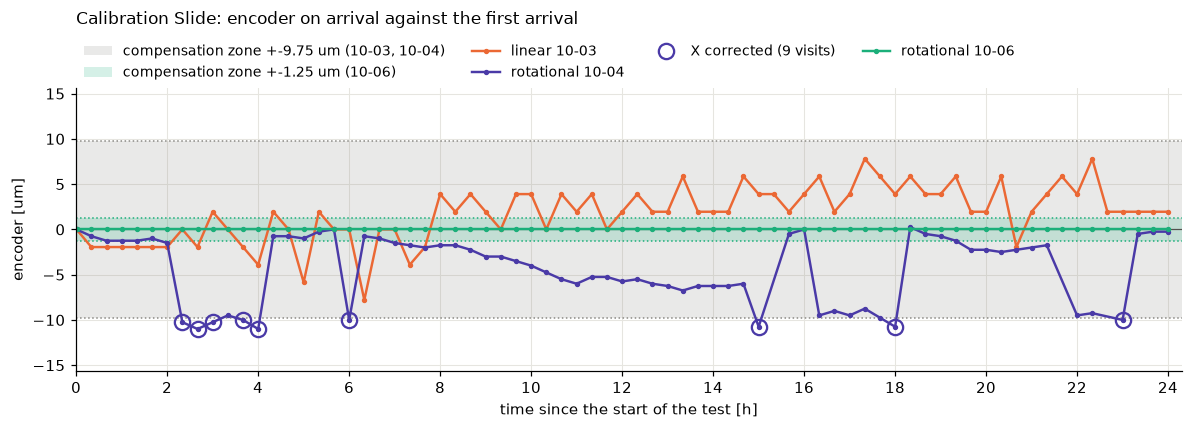

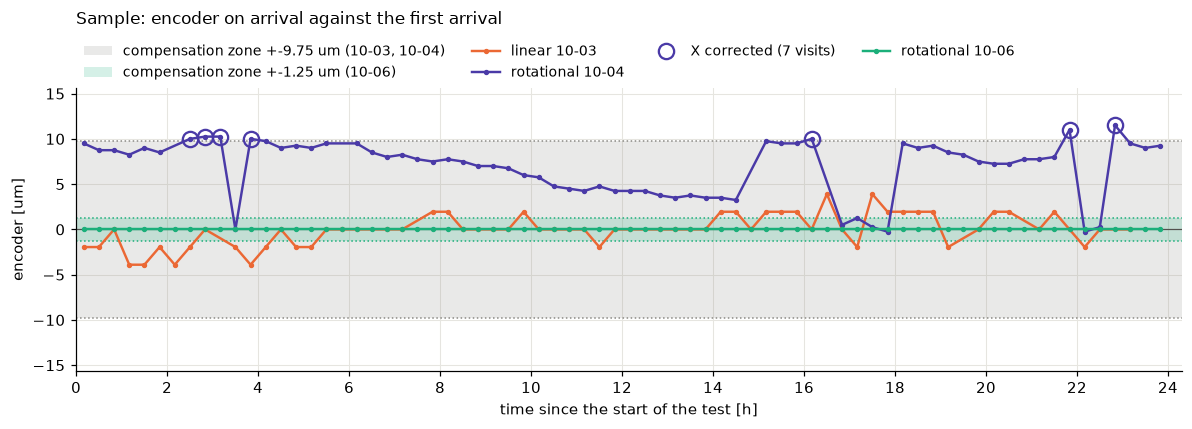

In [6]:
# compensation zones: 10-03 and 10-04 have the same one, so they share the grey band
zones = [
    (RUNS["linear 10-03"]["zone_um"], COLOR["zone"], "10-03, 10-04"),
    (RUNS["rotational 10-06"]["zone_um"], RUNS["rotational 10-06"]["color"], "10-06"),
]
y_max = 1.6 * RUNS["linear 10-03"]["zone_um"]

for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    for um, color, dates in zones:
        ax.axhspan(-um, um, color=color, alpha=0.18, lw=0, label=f"compensation zone +-{um:.2f} um ({dates})")
        ax.axhline(-um, color=color, ls=":", lw=1)
        ax.axhline(+um, color=color, ls=":", lw=1)

    for name, run in RUNS.items():
        shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "visit", "place", "compSteps", "event"])
        log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["visit", "encDriftCounts"])
        # encDriftCounts is only in the run CSV: put it next to the photo of the same visit
        photos = shift.merge(log, on="visit", how="left")
        photos = photos[photos["place"] == place]

        drift = photos["encDriftCounts"] * run["um_per_count"]
        lost = photos["event"].notna()                     # visits with lost steps: left out
        corrected = (photos["compSteps"] != 0) & ~lost     # X corrected, the encoder was out of the zone

        ax.plot(photos["hours"][~lost], drift[~lost], ".-", color=run["color"], label=name)
        if corrected.any():
            ax.plot(photos["hours"][corrected], drift[corrected], "o", mfc="none", mec=run["color"], ms=10,
                    mew=1.5, label=f"X corrected ({corrected.sum()} visits)")

    ax.set_title(f"{place.title()}: encoder on arrival against the first arrival", pad=42)   # pad = room for the legend
    ax.set(ylabel="encoder [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3), ylim=(-y_max, y_max))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"4_compensation_{place}.png".replace(" ", "_"))
    plt.show()

### 4.2 Where does the unseen shift come from?

`enc - dx` of part 3 again, one plot per run, with the lost-step events. A step
at a green line = the recovery left the stage at another place than the encoder
thinks; a slope between the lines = slow drift (temperature) the encoder cannot see.
The run of 10-06 has no green line: only the slow part and the scatter from photo to
photo are left.

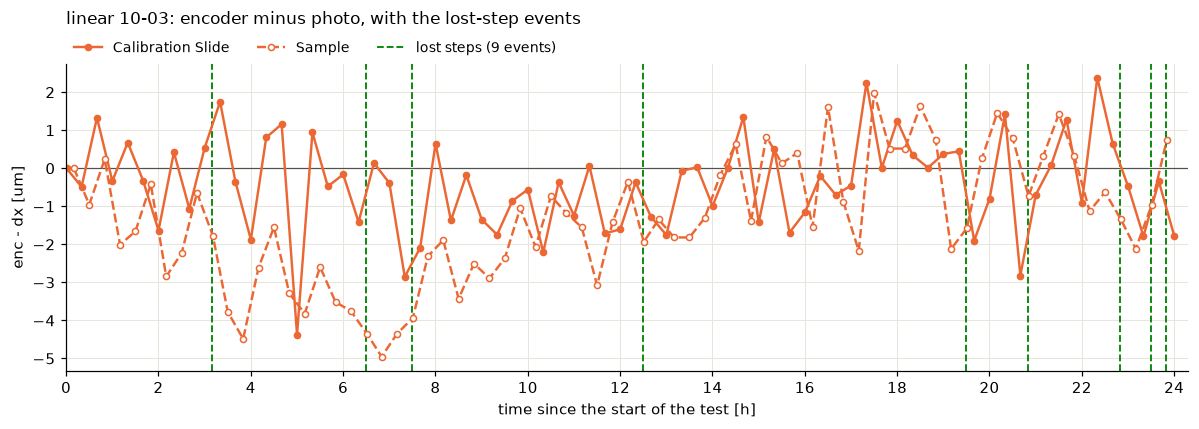

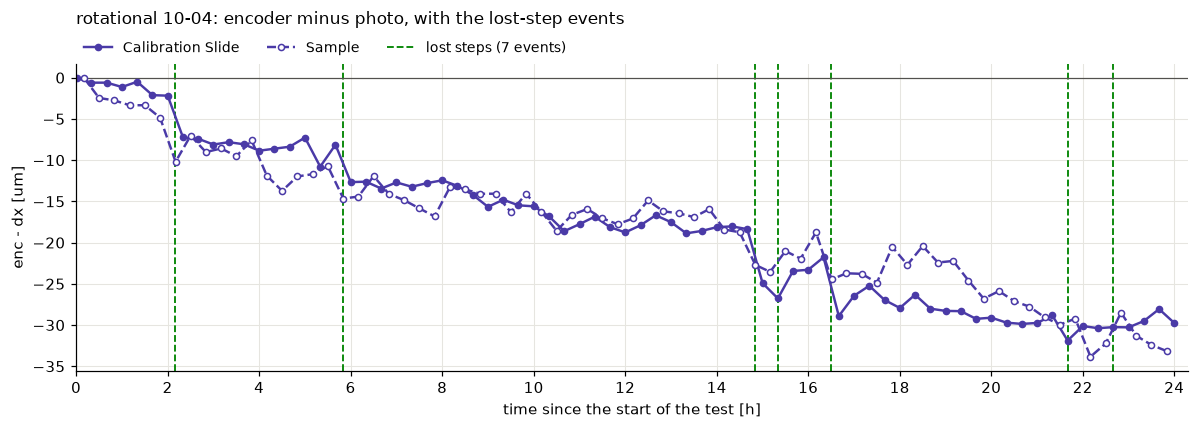

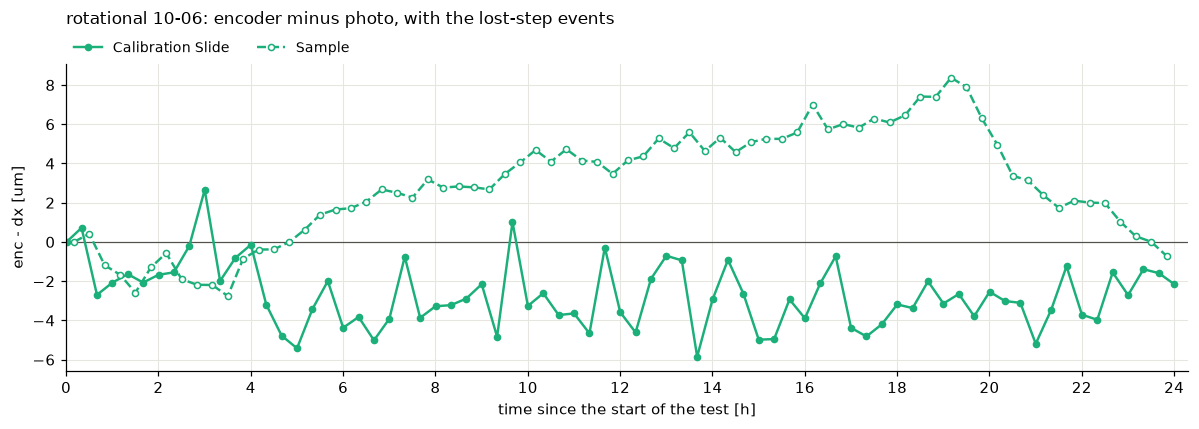

In [7]:
for name, run in RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "rawCounts", "dx_um"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move, in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = (lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)

    # enc = the count against the count at the first photo of the place, in um
    slide = shift[shift["place"] == "calibration slide"]
    sample = shift[shift["place"] == "sample"]
    enc_slide = (slide["rawCounts"] - slide["rawCounts"].iloc[0]) * run["um_per_count"]
    enc_sample = (sample["rawCounts"] - sample["rawCounts"].iloc[0]) * run["um_per_count"]

    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    ax.plot(slide["hours"], enc_slide - slide["dx_um"], "o-", color=run["color"], ms=4,
            label="Calibration Slide")
    ax.plot(sample["hours"], enc_sample - sample["dx_um"], "o--", color=run["color"], ms=4, mfc="white",
            label="Sample")
    for i, hours in enumerate(lost_hours):
        ax.axvline(hours, color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                   label=f"lost steps ({len(lost)} events)" if i == 0 else None)

    ax.set_title(f"{name}: encoder minus photo, with the lost-step events", pad=26)   # pad = room for the legend
    ax.set(ylabel="enc - dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"4_unseen_shift_{name}.png".replace(" ", "_"))
    plt.show()

### 4.3 Numbers

`dx step` = rms change of `dx` from one photo of a place to the next.
`at lost` = rms change of `enc - dx` between two photos of a place with a lost-step
event of the run in between, `else` = the same for all other pairs of photos.
`lost` = events on the way to this place, `corr.` = visits where X was corrected
because the encoder was out of the zone.

In [8]:
def rms(values):
    return f"{np.sqrt((values ** 2).mean()):.2f}" if len(values) else "-"


print(f"{'[um]':<34} {'dx min':>7} {'dx max':>7} {'dx end':>7} {'dx step':>7} {'dy min':>7} {'dy max':>7}   "
      f"{'enc - dx: rms':>13} {'end':>7} {'at lost':>8} {'else':>6}   {'lost':>4} {'corr.':>5}")
for name, run in RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"],
                        usecols=["hours", "place", "dx_um", "dy_um", "rawCounts", "compSteps", "event"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "place", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move, in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = ((lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)).to_numpy()

    for place in PLACES:
        photos = shift[shift["place"] == place]
        hours = photos["hours"].to_numpy()
        dx = photos["dx_um"].to_numpy()
        dy = photos["dy_um"].to_numpy()
        enc = (photos["rawCounts"].to_numpy() - photos["rawCounts"].iloc[0]) * run["um_per_count"]

        unseen = enc - dx          # enc - dx of part 3
        step = np.diff(unseen)     # its change from one photo to the next
        # True where a lost-step event of the run is between the two photos
        at_lost = np.array([((lost_hours > a) & (lost_hours <= b)).any() for a, b in zip(hours, hours[1:])])

        lost_to_here = (lost["place"] == place).sum()
        corrected = ((photos["compSteps"] != 0) & photos["event"].isna()).sum()

        print(f"{name:<16} {place:<17} {dx.min():>7.2f} {dx.max():>7.2f} {dx[-1]:>7.2f} "
              f"{rms(np.diff(dx)):>7} {dy.min():>7.2f} {dy.max():>7.2f}   "
              f"{rms(unseen):>13} {unseen[-1]:>7.2f} "
              f"{rms(step[at_lost]):>8} {rms(step[~at_lost]):>6}   "
              f"{lost_to_here:>4} {corrected:>5}")

[um]                                dx min  dx max  dx end dx step  dy min  dy max   enc - dx: rms     end  at lost   else   lost corr.
linear 10-03     calibration slide   -6.39    6.05    3.73    2.06   -1.79    0.00            1.30   -1.78     1.52   1.85      0     0
linear 10-03     sample              -0.29    6.90    1.19    0.85   -1.42    0.00            2.12    0.76     1.14   1.43      9     0
rotational 10-04 calibration slide   -1.68   33.38   29.51    3.94   -1.91    1.50           20.22  -29.76     4.67   1.16      3     9
rotational 10-04 sample              -2.47   32.91   32.91    4.13   -1.46    2.09           19.46  -33.16     4.02   1.83      4     7
rotational 10-06 calibration slide   -2.66    5.85    2.15    2.04   -1.51    0.06            3.16   -2.15        -   2.04      0     0
rotational 10-06 sample              -8.37    2.76    0.71    0.74   -0.91    1.15            4.02   -0.71        -   0.74      0     0


## 5. Lost steps: how often, and where the stage stopped

The table counts the moves at full speed (the first leg to each place is driven
slowly) and the lost-step events among them. `stopped at` = where the stage stood when
the move was over (`stallRawCounts` of the run), as the distance from the calibration slide.
`move` = median duration of a full-speed move (`xMoveSec`). `counts on arrival` = the
encoder against the first arrival at the place, over all visits without lost steps.

- 10-06 has no lost steps in 144 moves, the two runs before lost steps in 9 and in 7
  of 144. At the rate of those two runs (16 in 288) the chance of 144 moves in a row
  without one is about 0.03 %, so this is not luck.
- On the way to the sample the stage stopped between 53 and 73 mm from the calibration slide in both earlier runs, never in the first half of the travel.
- On the way to the calibration slide it stopped only on 10-04, 1.4 .. 6.0 mm before the
  target. That is the run with the shorter move: 4.6 s instead of 5.6 s for the same
  travel at the same speed, so with shorter ramps.
- The count on arrival does not scatter any more on 10-06 (10-04: up to 46 counts).

What the data cannot tell is why the stage does not stop any more. Between 10-04 and
10-06 the encoder pins were changed (and the slave flashed again), and both places
were taught again: against the reference photo of 10-03 the calibration slide was 59 um
off in y at the first try of 10-06 (correlation 0.63; on 10-04: 4 um, 0.96), so the
slide or the stage was moved in between.

In [9]:
def span(values, fmt="{:.0f}"):
    return f"{fmt.format(min(values))} .. {fmt.format(max(values))}" if len(values) else "-"


print(f"{'':<17} {'':>11} {'fast':>5}  {'to the sample':>20}  {'to the calibration slide':>24} "
      f"{'lost steps':>16} {'move':>6} {'counts on':>10}")
print(f"{'':<17} {'started':>11} {'moves':>5}  {'lost':>4} {'stopped at [mm]':>15}  {'lost':>8} "
      f"{'stopped at [mm]':>15} {'per event':>16} {'[s]':>6} {'arrival':>10}")
for name, run in RUNS.items():
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", parse_dates=["time_iso"],
                      usecols=["time_iso", "place", "rawCounts", "encDriftCounts", "event", "xMoveSec",
                               "lostSteps", "stallRawCounts"])
    started = log["time_iso"].min().strftime("%m-%d %H:%M")

    # the first leg to each place is driven slowly (about 31 s), all later ones at full speed
    fast = log[log["xMoveSec"] < 15]

    # where the stage stopped: the count after the lost-step move against the count at
    # the first arrival at the calibration slide, in mm
    lost = log[log["event"].notna()]
    count_at_slide = log.loc[log["place"] == "calibration slide", "rawCounts"].iloc[0]
    stopped_mm = (lost["stallRawCounts"] - count_at_slide).abs() * (abs(run["um_per_count"]) / 1000)
    to_sample = stopped_mm[lost["place"] == "sample"]
    to_slide = stopped_mm[lost["place"] == "calibration slide"]

    # the encoder on arrival against the first arrival, of all visits without lost steps
    on_arrival = log.loc[log["event"].isna(), "encDriftCounts"]

    print(f"{name:<17} {started:>11} {len(fast):>5}  "
          f"{len(to_sample):>4} {span(to_sample, '{:.1f}'):>15}  "
          f"{len(to_slide):>8} {span(to_slide, '{:.1f}'):>15} "
          f"{span(lost['lostSteps']):>16} {fast['xMoveSec'].median():>6.1f} "
          f"{span(on_arrival, '{:+.0f}'):>10}")

                               fast         to the sample  to the calibration slide       lost steps   move  counts on
                      started moves  lost stopped at [mm]      lost stopped at [mm]        per event    [s]    arrival
linear 10-03      10-03 11:04   144     9    53.1 .. 73.2         0               -  61526 .. 125874    5.6   -4 .. +4
rotational 10-04  10-04 15:15   144     4    57.0 .. 73.4         3      1.4 .. 6.0   4490 .. 113726    4.6 -46 .. +44
rotational 10-06  10-06 13:54   144     0               -         0               -                -    5.6   +0 .. +0


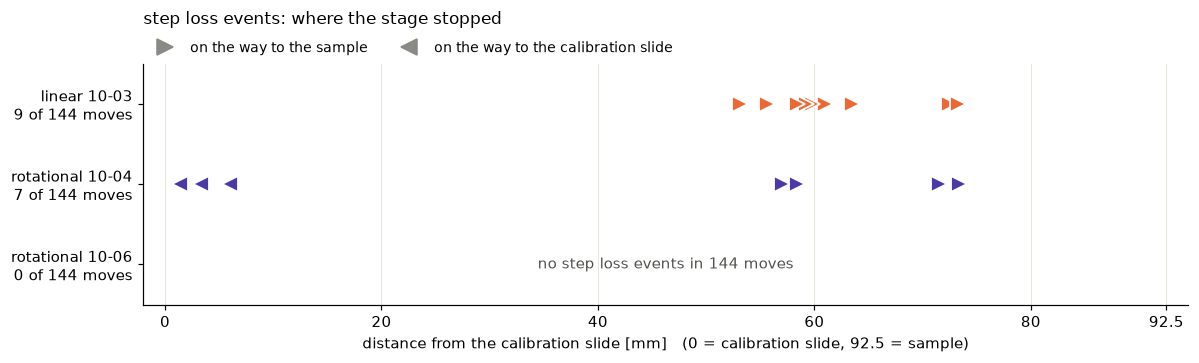

In [10]:
# from the run CSV of every run: where the stage stopped at the lost-step events,
# the number of full-speed moves, and the travel between the two places
stopped_to_sample, stopped_to_slide, fast_moves, travel_mm = {}, {}, {}, {}
for name, run in RUNS.items():
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#",
                      usecols=["place", "rawCounts", "event", "xMoveSec", "stallRawCounts"])
    mm_per_count = abs(run["um_per_count"]) / 1000
    # the count at the first arrival at each place
    count_at_slide = log.loc[log["place"] == "calibration slide", "rawCounts"].iloc[0]
    count_at_sample = log.loc[log["place"] == "sample", "rawCounts"].iloc[0]

    lost = log[log["event"].notna()]
    stopped_mm = (lost["stallRawCounts"] - count_at_slide).abs() * mm_per_count
    stopped_to_sample[name] = stopped_mm[lost["place"] == "sample"]
    stopped_to_slide[name] = stopped_mm[lost["place"] == "calibration slide"]
    fast_moves[name] = (log["xMoveSec"] < 15).sum()   # the first leg to each place is slow (about 31 s)
    travel_mm[name] = abs(count_at_sample - count_at_slide) * mm_per_count
travel = max(travel_mm.values())

fig, ax = plt.subplots(figsize=(11, 3.4))
tick_labels = []
for row, (name, run) in enumerate(RUNS.items()):
    to_sample, to_slide = stopped_to_sample[name], stopped_to_slide[name]
    ax.plot(to_sample, [row] * len(to_sample), ">", color=run["color"], ms=10, mec="white", mew=1.2)
    ax.plot(to_slide, [row] * len(to_slide), "<", color=run["color"], ms=10, mec="white", mew=1.2)
    lost_moves = len(to_sample) + len(to_slide)
    if lost_moves == 0:
        ax.text(travel / 2, row, f"no step loss events in {fast_moves[name]} moves", ha="center", va="center",
                color=COLOR["ink"], fontsize=10)
    tick_labels.append(f"{name}\n{lost_moves} of {fast_moves[name]} moves")
# the legend entries are grey: the colour of a marker is the run
ax.plot([], [], ">", color=COLOR["zone"], ms=10, label="on the way to the sample")
ax.plot([], [], "<", color=COLOR["zone"], ms=10, label="on the way to the calibration slide")

ax.set_title("step loss events: where the stage stopped", pad=26)   # pad = room for the legend
ax.set_yticks(range(len(RUNS)), tick_labels)
ax.set_ylim(len(RUNS) - 0.5, -0.5)
ax.set_xlim(-2, travel + 2)
ax.set_xticks([0, 20, 40, 60, 80, travel], ["0", "20", "40", "60", "80", f"{travel:.1f}"])
ax.set_xlabel(f"distance from the calibration slide [mm]   (0 = calibration slide, {travel:.1f} = sample)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "5_lost_steps_where.png")
plt.show()

## 6. 12 h thermal drift: nothing moves

`12hrstest_thermal_drift.py`: the stage is left where it is for 12 h, every 10 min a
photo is taken and the linear encoder and the step counters are read. No move is sent,
so what `dx` and `dy` show here is not the motor: it is the drift of the microscope
and of the sample (temperature), the part of the shifts of the 24 h test that no
encoder on the X axis can correct.

`enc` is as in the 24 h test: the raw count against the count at the first photo,
times 1.95 um.

`24hrstest_shift.py` only knows the photos of the 24 h test, so the photos of this run
are compared in the cell below, the same way: every photo with the first one, by cross
correlation of the two images (FFT, sub-pixel peak by a parabola fit). `corr` is the
height of the correlation peak: 1 = the same picture, only shifted. That takes about
4 s per photo, so the shifts in px are kept in `<drift run>_shift.csv` and the cell only
measures when that file is not there: delete it to measure again.

In [11]:
shift_path = DATA_DIR / DRIFT["shift_csv"]
if not shift_path.exists():
    rows = []
    for i, path in enumerate(sorted((DATA_DIR / DRIFT["photos"]).glob("*.png"))):
        img = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
        if i == 0:
            h, w = img.shape
            window = np.outer(np.hanning(h), np.hanning(w)).astype(np.float32)
            # drop the slow background (vignetting does not move): structures larger than 100 px
            keep = np.hypot(np.fft.rfftfreq(w)[None, :], np.fft.fftfreq(h)[:, None]) >= 1 / 100
        F = np.fft.rfft2((img - img.mean()) * window) * keep
        # sum of the squared pixels of the filtered photo (Parseval; the half spectrum of
        # rfft2 holds every column but the first and the Nyquist one twice)
        p = np.abs(F) ** 2
        energy = (2 * p.sum() - p[:, 0].sum() - p[:, -1].sum() * (w % 2 == 0)) / (h * w)
        if i == 0:
            F_first, energy_first = F, energy

        # cross correlation with the first photo: the peak is at the shift
        cc = np.fft.irfft2(np.conj(F_first) * F, s=(h, w))
        py, px = np.unravel_index(np.argmax(cc), cc.shape)
        # sub-pixel: parabola through the peak and its two neighbours
        peak, up, down, left, right = cc[py, px], cc[py - 1, px], cc[(py + 1) % h, px], cc[py, px - 1], cc[py, (px + 1) % w]
        dy = py + 0.5 * (up - down) / (up - 2 * peak + down)
        dx = px + 0.5 * (left - right) / (left - 2 * peak + right)
        dy = dy - h if dy > h / 2 else dy
        dx = dx - w if dx > w / 2 else dx
        rows.append(dict(photo=path.name, dx_px=round(float(dx), 3), dy_px=round(float(dy), 3),
                         corr=round(float(peak / np.sqrt(energy_first * energy)), 4)))
    pd.DataFrame(rows).to_csv(shift_path, index=False)

shift = pd.read_csv(shift_path, usecols=["photo", "corr"])
log = pd.read_csv(DATA_DIR / DRIFT["csv"], comment="#", usecols=["sample", "elapsed_s", "commanded", "y", "z"])
# the photo of a sample: the file name starts with the number of the sample (0019_<time>.png)
shift["sample"] = shift["photo"].str[:4].astype(int)
photos = shift.merge(log, on="sample")

# the step counters of X, Y and Z must not change
moved = photos[["commanded", "y", "z"]].nunique().max() > 1
print(f"{DRIFT['csv']}: {len(photos)} photos in {photos['elapsed_s'].max() / 3600:.1f} h, "
      f"corr {photos['corr'][1:].min():.2f} .. {photos['corr'][1:].max():.2f}, the step counters of "
      f"X, Y, Z {'CHANGED: something moved' if moved else 'did not change'}")

12hrstest_thermal_drift_x_20261005_184730.csv: 73 photos in 12.0 h, corr 0.77 .. 0.90, the step counters of X, Y, Z did not change


### 6.1 Shift of the photos against the first one

`dx` (red) and `dy` (blue) as in part 1, here with nothing moving in between.

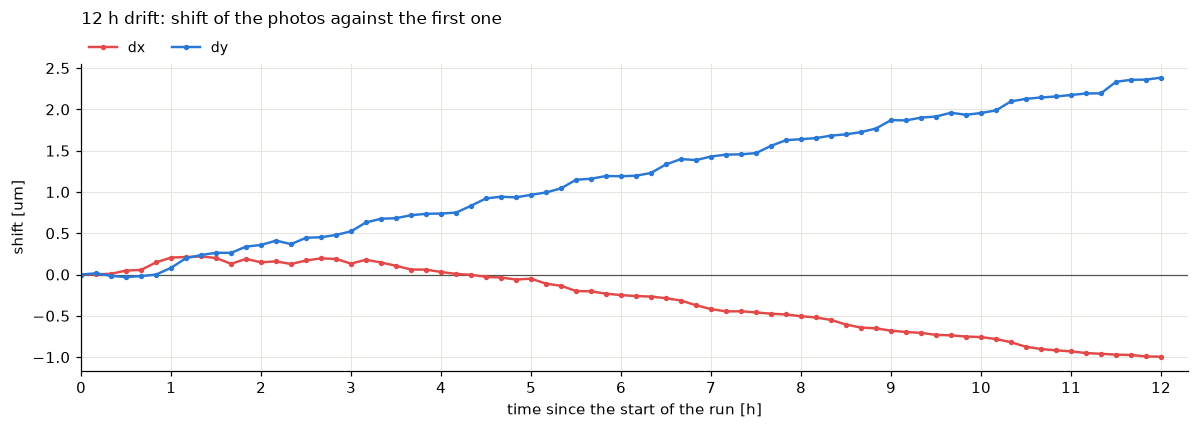

In [12]:
shift = pd.read_csv(DATA_DIR / DRIFT["shift_csv"], usecols=["photo", "dx_px", "dy_px"])
log = pd.read_csv(DATA_DIR / DRIFT["csv"], comment="#", usecols=["sample", "elapsed_s"])
# the photo of a sample: the file name starts with the number of the sample (0019_<time>.png)
shift["sample"] = shift["photo"].str[:4].astype(int)
photos = shift.merge(log, on="sample")

hours = photos["elapsed_s"] / 3600
dx = photos["dx_px"] * DRIFT["um_per_px"]
dy = photos["dy_px"] * DRIFT["um_per_px"]

fig, ax = plt.subplots()
ax.axhline(0, color=COLOR["ink"], lw=0.8)
ax.plot(hours, dx, ".-", color=COLOR["dx"], label="dx")
ax.plot(hours, dy, ".-", color=COLOR["dy"], label="dy")

ax.set_title("12 h drift: shift of the photos against the first one", pad=26)   # pad = room for the legend
ax.set(ylabel="shift [um]", xlabel="time since the start of the run [h]", xlim=(0, 12.3))
ax.set_xticks(range(0, 13))
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "6_drift_shift.png")
plt.show()

### 6.2 Encoder against the photo

`enc` (points) and `dx` (line) in one plot: what the linear encoder reports and what
the photo shows. One count is 1.95 um, so a drift below that can only show as the count
going back and forth between two neighbours.

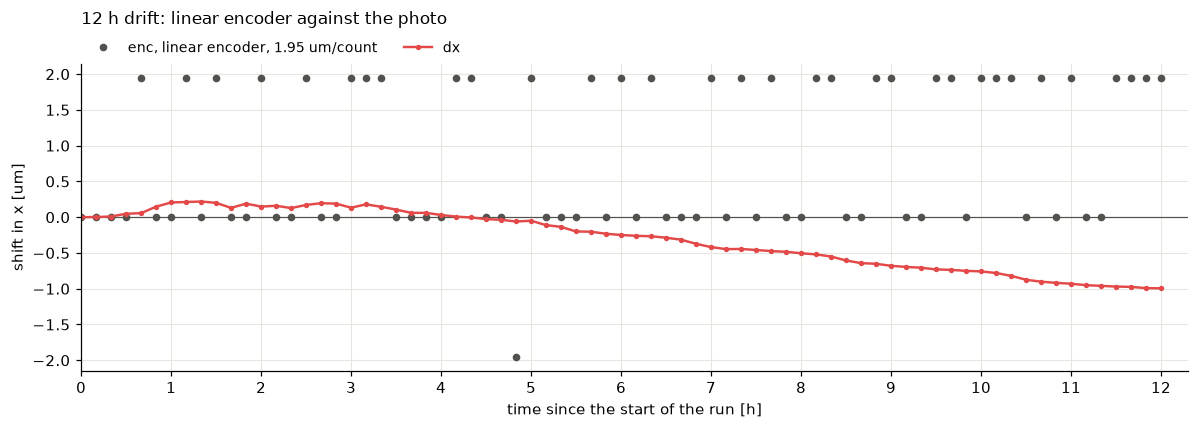

In [13]:
shift = pd.read_csv(DATA_DIR / DRIFT["shift_csv"], usecols=["photo", "dx_px"])
log = pd.read_csv(DATA_DIR / DRIFT["csv"], comment="#", usecols=["sample", "elapsed_s", "rawCounts"])
# the photo of a sample: the file name starts with the number of the sample (0019_<time>.png)
shift["sample"] = shift["photo"].str[:4].astype(int)
photos = shift.merge(log, on="sample")

hours = photos["elapsed_s"] / 3600
dx = photos["dx_px"] * DRIFT["um_per_px"]
# enc = the count against the count at the first photo, in um
enc = (photos["rawCounts"] - photos["rawCounts"].iloc[0]) * DRIFT["um_per_count"]

fig, ax = plt.subplots()
ax.axhline(0, color=COLOR["ink"], lw=0.8)
ax.plot(hours, enc, "o", color=COLOR["ink"], ms=4, label=f"enc, linear encoder, {abs(DRIFT['um_per_count']):g} um/count")
ax.plot(hours, dx, ".-", color=COLOR["dx"], label="dx")

ax.set_title("12 h drift: linear encoder against the photo", pad=26)   # pad = room for the legend
ax.set(ylabel="shift in x [um]", xlabel="time since the start of the run [h]", xlim=(0, 12.3))
ax.set_xticks(range(0, 13))
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "6_drift_encoder.png")
plt.show()

### 6.3 Against the 24 h test

`dx` and `dy` of the drift run in one plot with the sample photos of the three 24 h
runs, all against the time since the start of their run. The runs started at different
times of the day (24 h: 11:03, 15:14 and 13:53, drift: 18:47), so the curves are not
expected to lie on each other: the plots show how large the shift is that needs no move
at all.

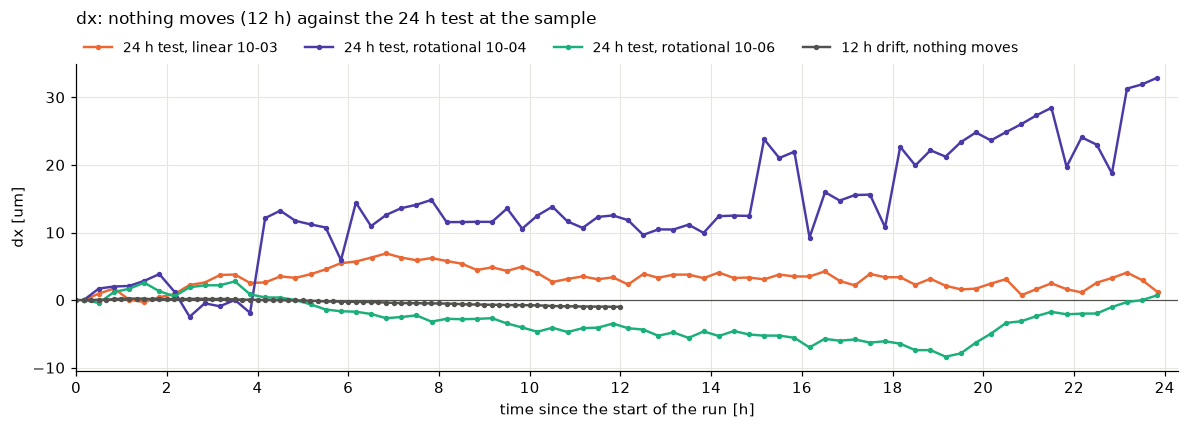

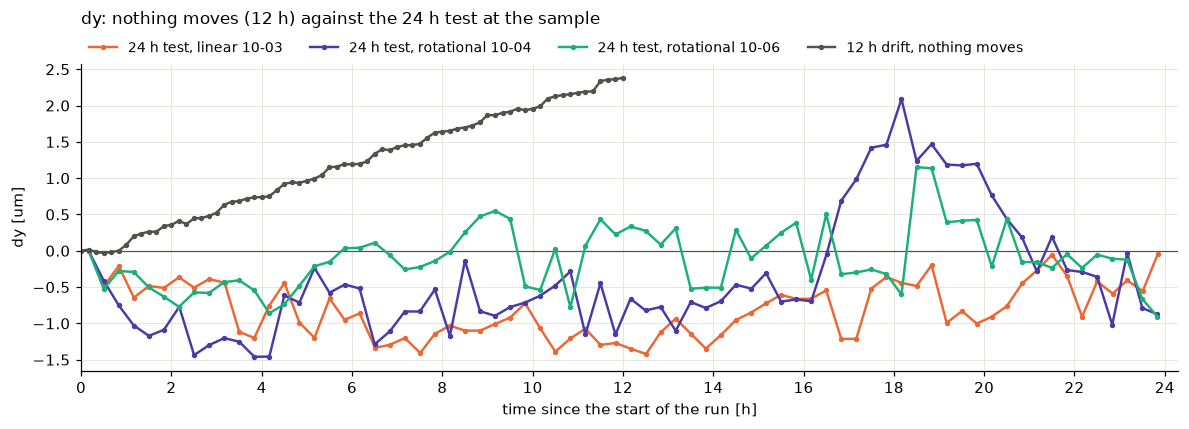

In [14]:
shift = pd.read_csv(DATA_DIR / DRIFT["shift_csv"], usecols=["photo", "dx_px", "dy_px"])
log = pd.read_csv(DATA_DIR / DRIFT["csv"], comment="#", usecols=["sample", "elapsed_s"])
# the photo of a sample: the file name starts with the number of the sample (0019_<time>.png)
shift["sample"] = shift["photo"].str[:4].astype(int)
drift = shift.merge(log, on="sample")
drift["hours"] = drift["elapsed_s"] / 3600
drift["dx_um"] = drift["dx_px"] * DRIFT["um_per_px"]
drift["dy_um"] = drift["dy_px"] * DRIFT["um_per_px"]

for axis in ("dx", "dy"):
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    for name, run in RUNS.items():
        photos = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", f"{axis}_um"])
        photos = photos[photos["place"] == "sample"]
        ax.plot(photos["hours"], photos[f"{axis}_um"], ".-", color=run["color"], label=f"24 h test, {name}")
    ax.plot(drift["hours"], drift[f"{axis}_um"], ".-", color=COLOR["ink"], label="12 h drift, nothing moves")

    ax.set_title(f"{axis}: nothing moves (12 h) against the 24 h test at the sample", pad=26)   # pad = room for the legend
    ax.set(ylabel=f"{axis} [um]", xlabel="time since the start of the run [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"6_drift_against_24h_{axis}.png")
    plt.show()

### 6.4 Numbers

`step` = rms change from one photo to the next: with nothing moving this is the noise
of the measurement plus 10 min of drift, in the 24 h test it also holds the error of
going away and coming back. `um/h` = slope of a line through the 12 h. The rows of the
24 h test are the sample photos of the first 12 h.

In [15]:
def rms(values):
    return f"{np.sqrt((values ** 2).mean()):.2f}" if len(values) else "-"


shift = pd.read_csv(DATA_DIR / DRIFT["shift_csv"], usecols=["photo", "dx_px", "dy_px"])
log = pd.read_csv(DATA_DIR / DRIFT["csv"], comment="#", usecols=["sample", "elapsed_s", "rawCounts"])
# the photo of a sample: the file name starts with the number of the sample (0019_<time>.png)
shift["sample"] = shift["photo"].str[:4].astype(int)
drift = shift.merge(log, on="sample")
drift_hours = (drift["elapsed_s"] / 3600).to_numpy()
drift_dx = (drift["dx_px"] * DRIFT["um_per_px"]).to_numpy()
drift_dy = (drift["dy_px"] * DRIFT["um_per_px"]).to_numpy()

# the rows of the table: label -> (hours, dx, dy)
table = {"12 h drift, nothing moves": (drift_hours, drift_dx, drift_dy)}
for name, run in RUNS.items():
    photos = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "dx_um", "dy_um"])
    photos = photos[(photos["place"] == "sample") & (photos["hours"] <= 12.2)]
    table[f"24 h test, {name}, 12 h"] = (photos["hours"].to_numpy(), photos["dx_um"].to_numpy(), photos["dy_um"].to_numpy())

print(f"{'[um]':<34}" + "".join(f" {a + ' min':>7} {a + ' max':>7} {a + ' end':>7} {'um/h':>7} {'step':>7}  " for a in ("dx", "dy")))
for label, (hours, dx, dy) in table.items():
    row = f"{label:<34}"
    for values in (dx, dy):
        row += (f" {values.min():>7.2f} {values.max():>7.2f} {values[-1]:>7.2f} "
                f"{np.polyfit(hours, values, 1)[0]:>7.3f} {rms(np.diff(values)):>7}  ")
    print(row)

# the encoder of the drift run: the count against the count at the first photo
counts = (drift["rawCounts"] - drift["rawCounts"].iloc[0]).to_numpy()
late = drift_hours >= 6
print(f"\nencoder: raw count {counts.min():+.0f} .. {counts.max():+.0f} against the first photo, not 0 in "
      f"{(counts[~late] != 0).sum()} of {(~late).sum()} samples of the first 6 h and in "
      f"{(counts[late] != 0).sum()} of {late.sum()} of the last 6 h; enc - dx: rms "
      f"{rms(counts * DRIFT['um_per_count'] - drift_dx)} um")

[um]                                dx min  dx max  dx end    um/h    step    dy min  dy max  dy end    um/h    step  
12 h drift, nothing moves            -0.99    0.22   -0.99  -0.110    0.03     -0.03    2.38    2.38   0.207    0.05  
24 h test, linear 10-03, 12 h        -0.29    6.90    2.31   0.291    0.75     -1.41    0.00   -1.35  -0.080    0.28  
24 h test, rotational 10-04, 12 h    -2.47   14.83   11.83   1.203    3.27     -1.46    0.00   -0.66   0.019    0.44  
24 h test, rotational 10-06, 12 h    -4.73    2.76   -4.16  -0.586    0.71     -0.86    0.55    0.33   0.060    0.32  

encoder: raw count -1 .. +1 against the first photo, not 0 in 13 of 36 samples of the first 6 h and in 20 of 37 of the last 6 h; enc - dx: rms 1.63 um


### 6.5 Visual check

The last photo against the first one. Left: overlay of the image centre, the first
photo in red, the last one in cyan - where they agree it is grey / black, a shift shows
up as coloured fringes. Right: the correlation peak (should be one clean maximum).

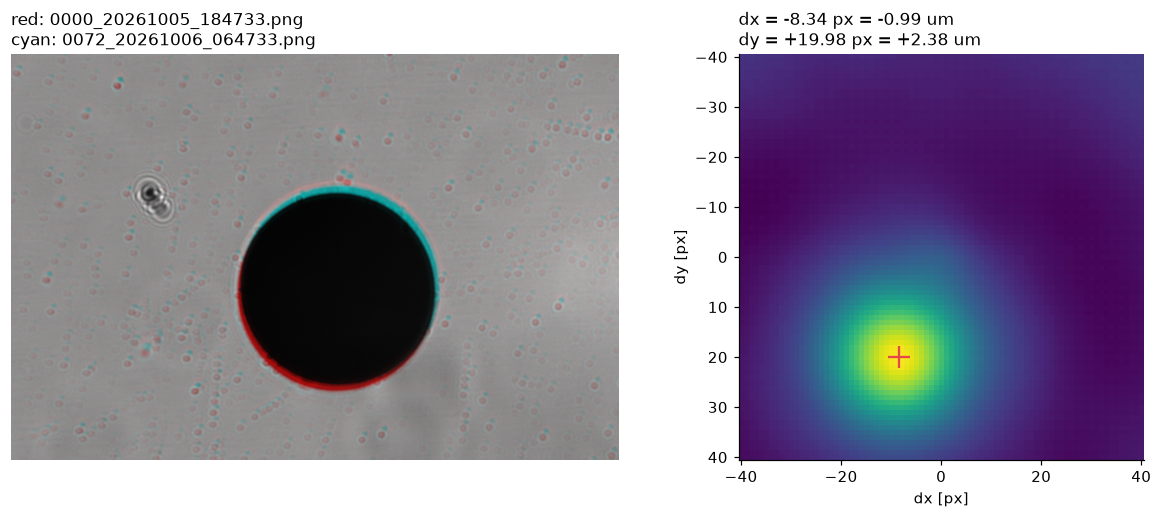

In [16]:
files = sorted((DATA_DIR / DRIFT["photos"]).glob("*.png"))
first = np.asarray(Image.open(files[0]).convert("L"), dtype=np.float32)
last = np.asarray(Image.open(files[-1]).convert("L"), dtype=np.float32)
h, w = first.shape

# cross correlation of the two photos, as in the first cell of this part
window = np.outer(np.hanning(h), np.hanning(w)).astype(np.float32)
keep = np.hypot(np.fft.rfftfreq(w)[None, :], np.fft.fftfreq(h)[:, None]) >= 1 / 100
F_first = np.fft.rfft2((first - first.mean()) * window) * keep
F_last = np.fft.rfft2((last - last.mean()) * window) * keep
cc = np.fft.irfft2(np.conj(F_first) * F_last, s=(h, w))
py, px = np.unravel_index(np.argmax(cc), cc.shape)
peak, up, down, left, right = cc[py, px], cc[py - 1, px], cc[(py + 1) % h, px], cc[py, px - 1], cc[py, (px + 1) % w]
dy = py + 0.5 * (up - down) / (up - 2 * peak + down)
dx = px + 0.5 * (left - right) / (left - 2 * peak + right)
dy = dy - h if dy > h / 2 else dy
dx = dx - w if dx > w / 2 else dx

# left: the centre of the two photos, each scaled to 0 .. 1, as the red and the cyan channel
centre = (slice(h // 2 - h // 6, h // 2 + h // 6), slice(w // 2 - w // 6, w // 2 + w // 6))
red = (first[centre] - first[centre].min()) / np.ptp(first[centre])
cyan = (last[centre] - last[centre].min()) / np.ptp(last[centre])
# right: the correlation around its peak, +- z px
z = 40
around_peak = np.fft.fftshift(cc)[h // 2 - z:h // 2 + z + 1, w // 2 - z:w // 2 + z + 1]

fig, (ax_photo, ax_peak) = plt.subplots(1, 2, figsize=(11, 4.6), width_ratios=(1.5, 1), layout="constrained")
ax_photo.imshow(np.dstack([red, cyan, cyan]))
ax_photo.set_title(f"red: {files[0].name}\ncyan: {files[-1].name}")
ax_photo.axis("off")
ax_peak.imshow(around_peak, extent=(-z - .5, z + .5, z + .5, -z - .5), cmap="viridis")
ax_peak.plot(dx, dy, "+", color=COLOR["dx"], ms=14, mew=1.5)
ax_peak.set_title(f"dx = {dx:+.2f} px = {dx * DRIFT['um_per_px']:+.2f} um\n"
                  f"dy = {dy:+.2f} px = {dy * DRIFT['um_per_px']:+.2f} um")
ax_peak.set(xlabel="dx [px]", ylabel="dy [px]")
ax_peak.grid(False)
fig.savefig(PLOT_DIR / "6_drift_check.png")
plt.show()

## 7. Ultra test: the 24 h test with random moves in between

`ultra_test_can_linear.py`, `ultra_test_can_rotational.py`: the visits and the photos of
the 24 h test, and between two visits X makes 2 .. 5 moves to random places between the
calibration slide and the sample, then goes back to the place of the last photo. All at
100000 steps/s like the 24 h test, but with an acceleration of 1000000 steps/s^2 (24 h
test: 100000).

| run | encoder | compensation zone | full-speed moves | lost-step events |
|---|---|---|---|---|
| `ultra linear 10-07` | linear (magnetic), 1.95 um per count | 4 counts = 7.80 um | 140 legs + 639 random moves | 4, all in random moves |

The cells are those of parts 1 - 5, for the runs in `ULTRA_RUNS` (first cell). What is
different in the data:

- Steps can be lost in a random move too. Such an event is in the row of the next visit
  of `<run>.csv` (`walkLost` = which random move), with the start of that random move in
  `xMoveStart`, so the green lines are drawn as before. The stage is brought back when
  that visit is due: its photo is taken after the recovery.
- `<run>_walk.csv` has one row per random move and per way back. It is used in 7.7, to
  count the moves and for the direction of the move that lost the steps.

### 7.1 Shift of the photos against the first one

As part 1: one plot per run and place, `dx` (red) and `dy` (blue). The green dashed
lines are the lost-step events of the run, at the start of the move in which the steps
were lost: a leg or a random move.

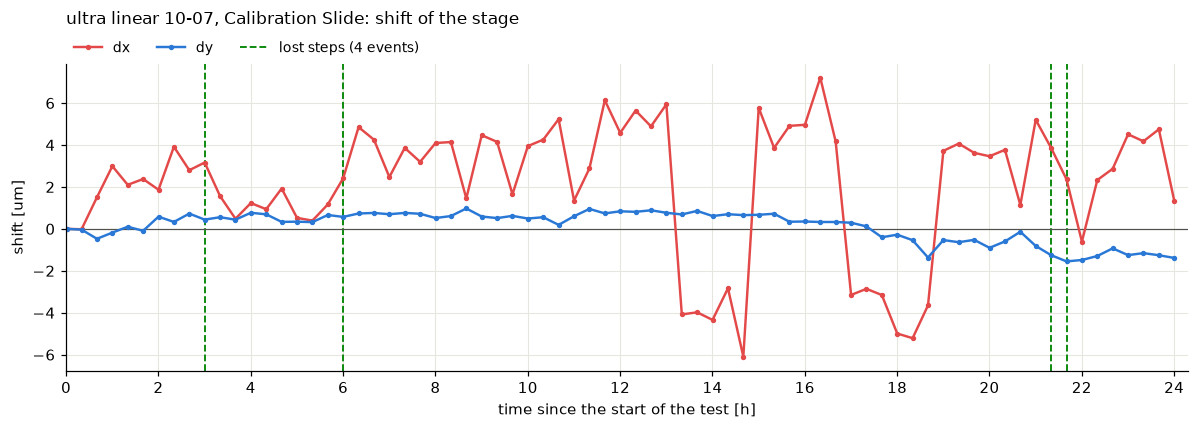

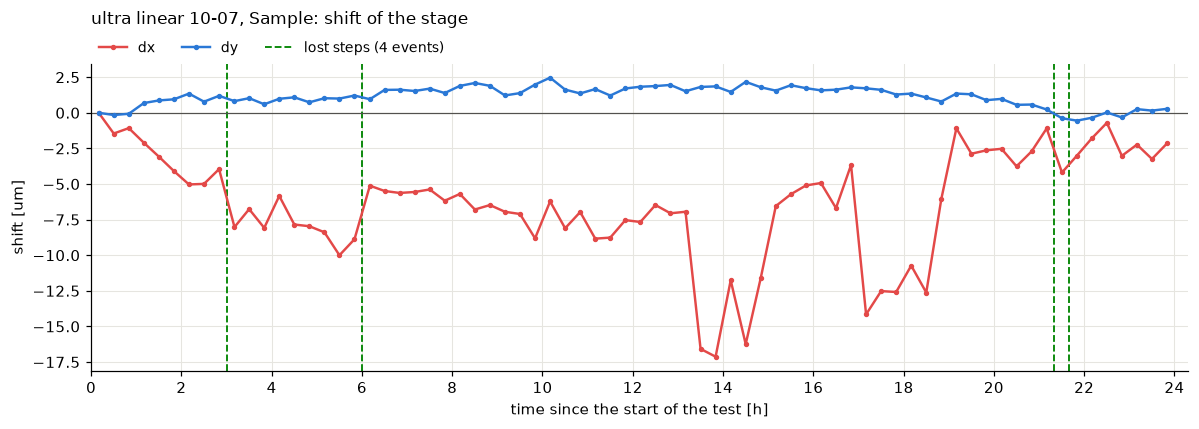

In [17]:
for name, run in ULTRA_RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "dx_um", "dy_um"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move (a leg or a random move), in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = (lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)

    for place in PLACES:
        photos = shift[shift["place"] == place]

        fig, ax = plt.subplots()
        ax.axhline(0, color=COLOR["ink"], lw=0.8)
        ax.plot(photos["hours"], photos["dx_um"], ".-", color=COLOR["dx"], label="dx")
        ax.plot(photos["hours"], photos["dy_um"], ".-", color=COLOR["dy"], label="dy")
        for i, hours in enumerate(lost_hours):
            ax.axvline(hours, color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                       label=f"lost steps ({len(lost)} events)" if i == 0 else None)

        ax.set_title(f"{name}, {place.title()}: shift of the stage", pad=26)   # pad = room for the legend
        ax.set(ylabel="shift [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
        ax.set_xticks(range(0, 25, 2))
        ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
        fig.tight_layout()
        fig.savefig(PLOT_DIR / f"7_1_shift_{name}_{place}.png".replace(" ", "_"))
        plt.show()

### 7.2 dx, with the compensation zone

As part 2: `dx` of the ultra runs in one plot per place, with the zone of each run
around the first photo. The y axis is the same in both plots.

On 10-07 `dx` stays within -6.1 .. +7.2 um at the calibration slide. At the sample it
is -10 .. 0 um, but for two blocks of about 1.5 h (13.5 - 15 h and 17 - 18.5 h) at
-11 .. -17 um, out of the +-7.80 um zone, without being corrected: see 7.4.

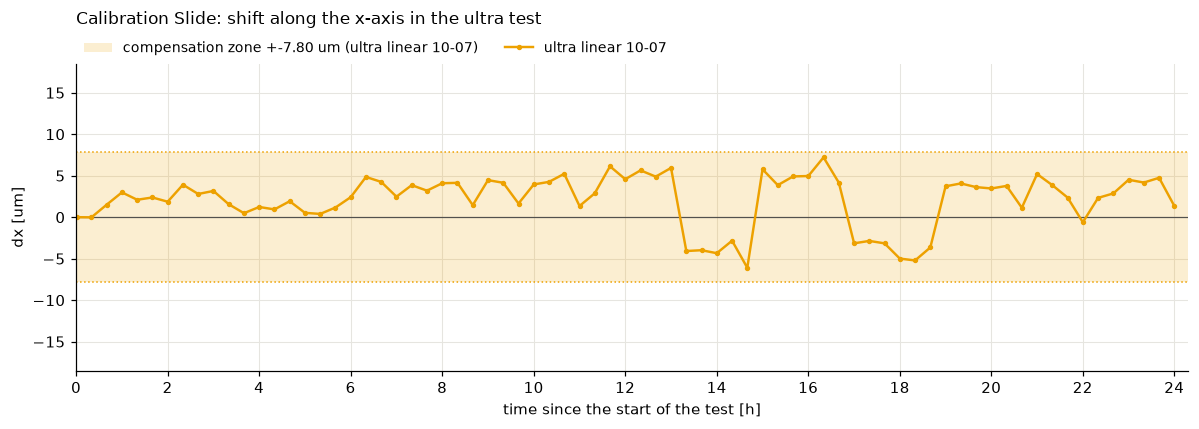

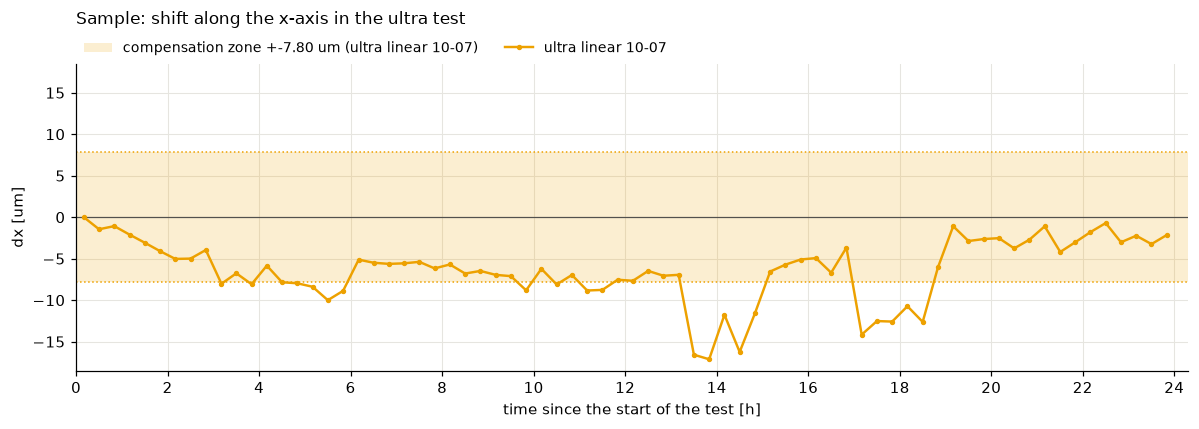

In [18]:
shift = {name: pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "dx_um"])
         for name, run in ULTRA_RUNS.items()}

# the same y axis in both plots: just above the largest dx and the widest zone of all runs
y_max = 1.08 * max(max(s["dx_um"].abs().max() for s in shift.values()),
                   max(run["zone_um"] for run in ULTRA_RUNS.values()))

for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    # compensation zones: one band per run, in the colour of the run
    for name, run in ULTRA_RUNS.items():
        um = run["zone_um"]
        ax.axhspan(-um, um, color=run["color"], alpha=0.18, lw=0, label=f"compensation zone +-{um:.2f} um ({name})")
        ax.axhline(-um, color=run["color"], ls=":", lw=1)
        ax.axhline(+um, color=run["color"], ls=":", lw=1)
    for name, run in ULTRA_RUNS.items():
        photos = shift[name][shift[name]["place"] == place]
        ax.plot(photos["hours"], photos["dx_um"], ".-", color=run["color"], label=name)

    ax.set_title(f"{place.title()}: shift along the x-axis in the ultra test", pad=26)   # pad = room for the legend
    ax.set(ylabel="dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3), ylim=(-y_max, y_max))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"7_2_dx_{place}.png".replace(" ", "_"))
    plt.show()

### 7.3 Encoder minus photo: did the encoder see the shift?

As part 3: `enc - dx`, 0 = the encoder reports exactly what the photo shows. The cell
below checks the um per count with the photos first: the change of `dx` from one photo
to the next against the change of the count.

On 10-07 the count changes by up to 6 from photo to photo and `dx` follows it (r =
+0.90), so the linear encoder does see where the stage arrives. At the calibration
slide `enc - dx` stays within -1.5 .. +4 um. At the sample it rises to +6 um in the
first 2 h, is mostly +7 .. +9 um from 7 to 14 h and comes back to +2 .. +5 um at the end: a
shift of the picture the encoder does not know about, slow like the drift of part 6.

In [19]:
for name, run in ULTRA_RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["place", "rawCounts", "dx_um"])

    # the change of the count and of dx from one photo of a place to the next
    change = shift.groupby("place").diff().dropna()
    d_counts, d_dx = change["rawCounts"], change["dx_um"]

    if (d_counts == 0).all():
        print(f"{name:<19} the count is the same at every photo of a place: nothing to fit, "
              f"dx moves {np.sqrt((d_dx ** 2).mean()):.2f} um rms from photo to photo")
    else:
        moved = d_counts != 0
        fit = (d_counts * d_dx).sum() / (d_counts ** 2).sum()   # slope of the line through 0
        r = np.corrcoef(d_counts[moved], d_dx[moved])[0, 1]
        print(f"{name:<19} count changes up to {d_counts.abs().max():.0f}: dx moves "
              f"{fit:+.2f} um per count (r = {r:+.2f}, used: {run['um_per_count']:+.2f})")

ultra linear 10-07  count changes up to 6: dx moves +1.50 um per count (r = +0.90, used: +1.95)


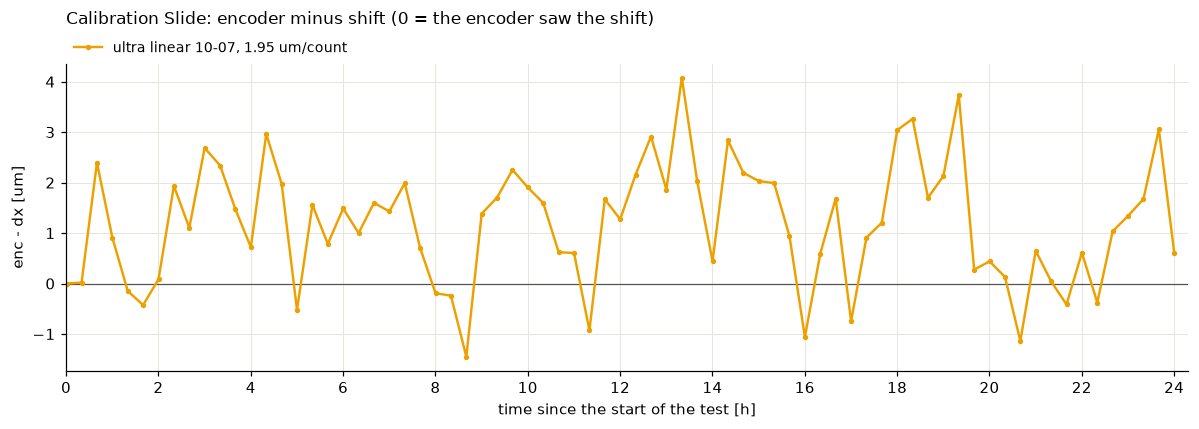

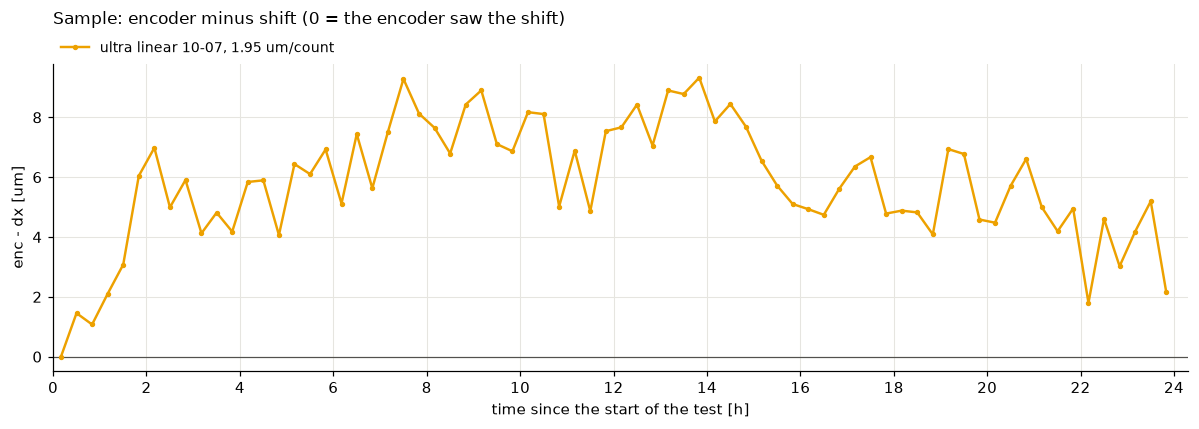

In [20]:
for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    for name, run in ULTRA_RUNS.items():
        shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "rawCounts", "dx_um"])
        photos = shift[shift["place"] == place]
        # enc = the count against the count at the first photo of the place, in um
        enc = (photos["rawCounts"] - photos["rawCounts"].iloc[0]) * run["um_per_count"]
        ax.plot(photos["hours"], enc - photos["dx_um"], ".-", color=run["color"],
                label=f"{name}, {abs(run['um_per_count']):g} um/count")

    ax.set_title(f"{place.title()}: encoder minus shift (0 = the encoder saw the shift)", pad=26)   # pad = room for the legend
    ax.set(ylabel="enc - dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"7_3_encoder_minus_photo_{place}.png".replace(" ", "_"))
    plt.show()

### 7.4 What the compensation saw

As 4.1: the encoder on arrival, before any correction, against the first arrival at the
place (`encDriftCounts` of the run, in um), and the zone. The circles are the visits
where it was outside and X was corrected; the visits with lost steps are left out.

On 10-07 X was corrected at 3 visits of each place, every time by 31 steps (5 counts):
-31 at the calibration slide, +31 at the sample. A correction moves the targets of both
places. After one at the calibration slide the sample is reached 3 or 4 counts low, which
is still inside the zone (a correction needs more than 4 counts), so nothing is corrected
there until a visit arrives 5 counts low: these are the two blocks of `dx` at the
sample in 7.2.

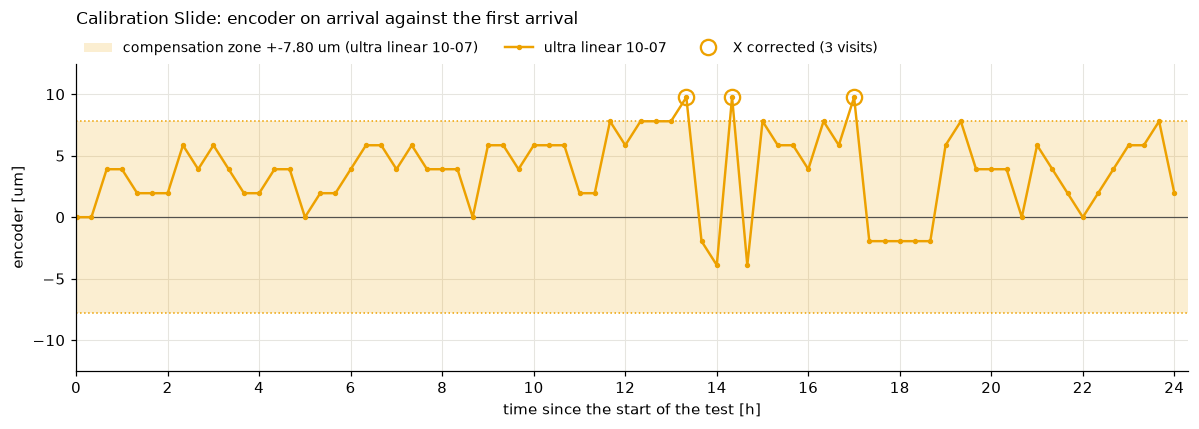

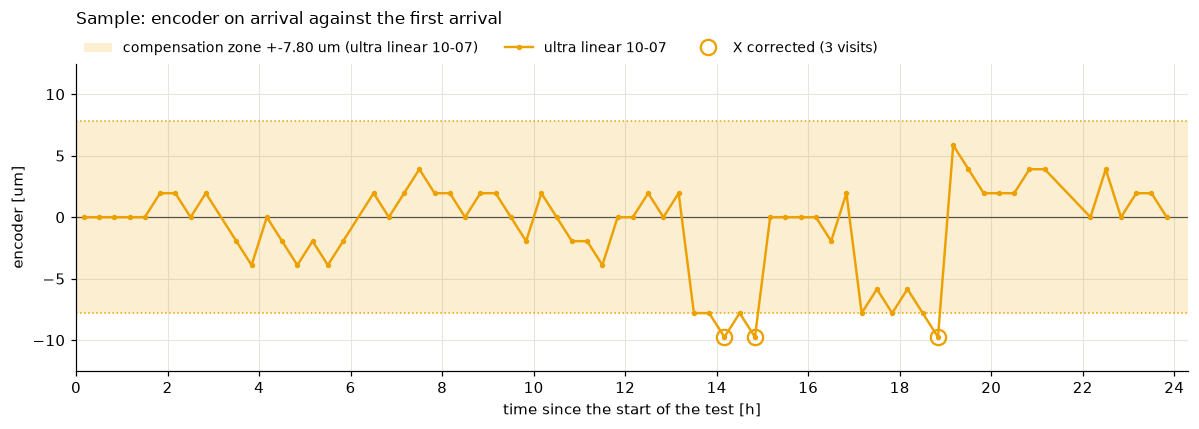

In [21]:
y_max = 1.6 * max(run["zone_um"] for run in ULTRA_RUNS.values())

for place in PLACES:
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    # compensation zones: one band per run, in the colour of the run
    for name, run in ULTRA_RUNS.items():
        um = run["zone_um"]
        ax.axhspan(-um, um, color=run["color"], alpha=0.18, lw=0, label=f"compensation zone +-{um:.2f} um ({name})")
        ax.axhline(-um, color=run["color"], ls=":", lw=1)
        ax.axhline(+um, color=run["color"], ls=":", lw=1)

    for name, run in ULTRA_RUNS.items():
        shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "visit", "place", "compSteps", "event"])
        log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["visit", "encDriftCounts"])
        # encDriftCounts is only in the run CSV: put it next to the photo of the same visit
        photos = shift.merge(log, on="visit", how="left")
        photos = photos[photos["place"] == place]

        drift = photos["encDriftCounts"] * run["um_per_count"]
        lost = photos["event"].notna()                     # visits with lost steps: left out
        corrected = (photos["compSteps"] != 0) & ~lost     # X corrected, the encoder was out of the zone

        ax.plot(photos["hours"][~lost], drift[~lost], ".-", color=run["color"], label=name)
        if corrected.any():
            ax.plot(photos["hours"][corrected], drift[corrected], "o", mfc="none", mec=run["color"], ms=10,
                    mew=1.5, label=f"X corrected ({corrected.sum()} visits)")

    ax.set_title(f"{place.title()}: encoder on arrival against the first arrival", pad=26)   # pad = room for the legend
    ax.set(ylabel="encoder [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3), ylim=(-y_max, y_max))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"7_4_compensation_{place}.png".replace(" ", "_"))
    plt.show()

### 7.5 Where does the unseen shift come from?

As 4.2: `enc - dx` of 7.3 again, one plot per run, with the lost-step events. A step at
a green line = the recovery left the stage at another place than the encoder thinks; a
slope between the lines = slow drift (temperature) the encoder cannot see.

On 10-07 there is no step at the four green lines (7.6: `enc - dx` changes by 0.6 and
1.4 um rms across an event, 1.4 and 1.5 um between any other two photos): after losing
up to 153352 steps the stage is back where the encoder says. What is left at the sample
is the slow part.

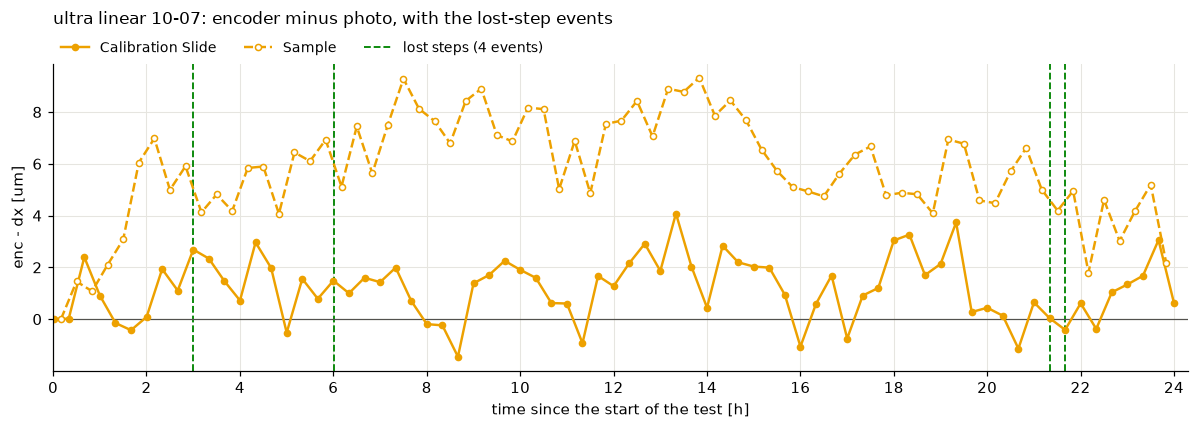

In [22]:
for name, run in ULTRA_RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"], usecols=["hours", "place", "rawCounts", "dx_um"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move (a leg or a random move), in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = (lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)

    # enc = the count against the count at the first photo of the place, in um
    slide = shift[shift["place"] == "calibration slide"]
    sample = shift[shift["place"] == "sample"]
    enc_slide = (slide["rawCounts"] - slide["rawCounts"].iloc[0]) * run["um_per_count"]
    enc_sample = (sample["rawCounts"] - sample["rawCounts"].iloc[0]) * run["um_per_count"]

    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    ax.plot(slide["hours"], enc_slide - slide["dx_um"], "o-", color=run["color"], ms=4,
            label="Calibration Slide")
    ax.plot(sample["hours"], enc_sample - sample["dx_um"], "o--", color=run["color"], ms=4, mfc="white",
            label="Sample")
    for i, hours in enumerate(lost_hours):
        ax.axvline(hours, color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                   label=f"lost steps ({len(lost)} events)" if i == 0 else None)

    ax.set_title(f"{name}: encoder minus photo, with the lost-step events", pad=26)   # pad = room for the legend
    ax.set(ylabel="enc - dx [um]", xlabel="time since the start of the test [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"7_5_unseen_shift_{name}.png".replace(" ", "_"))
    plt.show()

### 7.6 Numbers

As 4.3. `dx step` = rms change of `dx` from one photo of a place to the next.
`at lost` = rms change of `enc - dx` between two photos of a place with a lost-step
event of the run in between, `else` = the same for all other pairs of photos.
`lost` = events before a visit of this place (in the leg to it or in the random moves
before it; the photo of that visit is taken after the recovery), `corr.` = visits where
X was corrected because the encoder was out of the zone.

In [23]:
def rms(values):
    return f"{np.sqrt((values ** 2).mean()):.2f}" if len(values) else "-"


print(f"{'[um]':<36} {'dx min':>7} {'dx max':>7} {'dx end':>7} {'dx step':>7} {'dy min':>7} {'dy max':>7}   "
      f"{'enc - dx: rms':>13} {'end':>7} {'at lost':>8} {'else':>6}   {'lost':>4} {'corr.':>5}")
for name, run in ULTRA_RUNS.items():
    shift = pd.read_csv(DATA_DIR / run["shift_csv"],
                        usecols=["hours", "place", "dx_um", "dy_um", "rawCounts", "compSteps", "event"])
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", usecols=["time_iso", "place", "event", "xMoveStart"],
                      parse_dates=["time_iso", "xMoveStart"])

    # lost-step events = the rows of the run CSV with something in the event column,
    # at the start of that move (a leg or a random move), in hours since the first row
    lost = log[log["event"].notna()]
    lost_hours = ((lost["xMoveStart"] - log["time_iso"].min()) / pd.Timedelta(hours=1)).to_numpy()

    for place in PLACES:
        photos = shift[shift["place"] == place]
        hours = photos["hours"].to_numpy()
        dx = photos["dx_um"].to_numpy()
        dy = photos["dy_um"].to_numpy()
        enc = (photos["rawCounts"].to_numpy() - photos["rawCounts"].iloc[0]) * run["um_per_count"]

        unseen = enc - dx          # enc - dx of 7.3
        step = np.diff(unseen)     # its change from one photo to the next
        # True where a lost-step event of the run is between the two photos
        at_lost = np.array([((lost_hours > a) & (lost_hours <= b)).any() for a, b in zip(hours, hours[1:])])

        lost_before_here = (lost["place"] == place).sum()
        corrected = ((photos["compSteps"] != 0) & photos["event"].isna()).sum()

        print(f"{name:<18} {place:<17} {dx.min():>7.2f} {dx.max():>7.2f} {dx[-1]:>7.2f} "
              f"{rms(np.diff(dx)):>7} {dy.min():>7.2f} {dy.max():>7.2f}   "
              f"{rms(unseen):>13} {unseen[-1]:>7.2f} "
              f"{rms(step[at_lost]):>8} {rms(step[~at_lost]):>6}   "
              f"{lost_before_here:>4} {corrected:>5}")

[um]                                  dx min  dx max  dx end dx step  dy min  dy max   enc - dx: rms     end  at lost   else   lost corr.
ultra linear 10-07 calibration slide   -6.10    7.21    1.34    2.75   -1.55    0.97            1.68    0.61     0.64   1.40      0     3
ultra linear 10-07 sample             -17.13   -0.00   -2.15    2.65   -0.55    2.47            6.15    2.15     1.39   1.49      4     3


### 7.7 Lost steps: how often, and where the stage stopped

As part 5. `fast moves` = the moves at full speed: the legs (the first leg to each place
and the leg after a random move that lost steps are driven slowly and not counted) and
the rows of `<run>_walk.csv` (random moves and ways back). `lost in` = events in a leg /
in a random move. `stopped at` = where the stage stood when the move was over
(`stallRawCounts` of the run), as the distance from the calibration slide, by the
direction of the move that lost the steps. `leg` = median duration of a full-speed leg
(`xMoveSec`). `counts on arrival` = the encoder against the first arrival at the place,
over all visits without lost steps.

- 10-07 lost steps in 4 of 779 full-speed moves, all 4 in random moves and none in the
  140 legs. The run of 10-03 with the same encoder lost steps in 9 of 144 legs (part 5).
- Moving towards the sample the stage stopped 23.3 and 34.2 mm from the calibration
  slide (both in the first random move after a visit of the calibration slide); on
  10-03 it stopped at 53 .. 73 mm.
- On the way back to the calibration slide it stopped 2.2 and 3.1 mm before it.
- With four events the data cannot tell what they depend on: the ultra test differs
  from the 24 h test in the acceleration (1000000 instead of 100000) and in the number
  and the length of the moves.

In [24]:
def span(values, fmt="{:.0f}"):
    return f"{fmt.format(min(values))} .. {fmt.format(max(values))}" if len(values) else "-"


print(f"{'':<19} {'':>11} {'fast moves':>13}  {'lost in':>13}  {'towards the sample':>20}  {'towards the cal. slide':>22} "
      f"{'lost steps':>16} {'leg':>5} {'counts on':>10}")
print(f"{'':<19} {'started':>11} {'legs':>5} {'random':>7}  {'legs':>5} {'random':>7}  {'lost':>4} {'stopped at [mm]':>15}  "
      f"{'lost':>6} {'stopped at [mm]':>15} {'per event':>16} {'[s]':>5} {'arrival':>10}")
for name, run in ULTRA_RUNS.items():
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#", parse_dates=["time_iso"],
                      usecols=["time_iso", "visit", "place", "move", "rawCounts", "encDriftCounts", "event",
                               "xMoveSec", "lostSteps", "stallRawCounts", "walkLost"])
    walk = pd.read_csv(DATA_DIR / run["walk_csv"], usecols=["visit", "move", "event"])
    started = log["time_iso"].min().strftime("%m-%d %H:%M")

    # moves at full speed: the legs (but the first one to each place, about 31 s, and the leg
    # after a random move that lost steps: both are driven slowly) and every row of the
    # walk CSV (the random moves and the ways back)
    fast_legs = log[(log["xMoveSec"] < 15) & log["walkLost"].isna()]

    lost = log[log["event"].notna()]
    in_random = lost["walkLost"].notna()   # lost in a random move, not in the leg of that row
    # the move that lost the steps: the row of the walk CSV with the event, else the leg.
    # Towards the sample = it has the sign of the first leg to the sample
    lost_random_move = walk[walk["event"].notna()].set_index("visit")["move"]
    lost_move = lost["visit"].map(lost_random_move).fillna(lost["move"])
    towards_sample = np.sign(lost_move) == np.sign(log.loc[log["place"] == "sample", "move"].iloc[0])

    # where the stage stopped: the count after the lost-step move against the count at
    # the first arrival at the calibration slide, in mm
    count_at_slide = log.loc[log["place"] == "calibration slide", "rawCounts"].iloc[0]
    stopped_mm = (lost["stallRawCounts"] - count_at_slide).abs() * (abs(run["um_per_count"]) / 1000)
    to_sample = stopped_mm[towards_sample]
    to_slide = stopped_mm[~towards_sample]

    # the encoder on arrival against the first arrival, of all visits without lost steps
    on_arrival = log.loc[log["event"].isna(), "encDriftCounts"]

    print(f"{name:<19} {started:>11} {len(fast_legs):>5} {len(walk):>7}  "
          f"{(~in_random).sum():>5} {in_random.sum():>7}  "
          f"{len(to_sample):>4} {span(to_sample, '{:.1f}'):>15}  "
          f"{len(to_slide):>6} {span(to_slide, '{:.1f}'):>15} "
          f"{span(lost['lostSteps']):>16} {fast_legs['xMoveSec'].median():>5.1f} "
          f"{span(on_arrival, '{:+.0f}'):>10}")

                                   fast moves        lost in    towards the sample  towards the cal. slide       lost steps   leg  counts on
                        started  legs  random   legs  random  lost stopped at [mm]    lost stopped at [mm]        per event   [s]    arrival
ultra linear 10-07  10-07 17:25   140     639      0       4     2    23.3 .. 34.2       2      2.2 .. 3.1   7062 .. 153352   4.6   -5 .. +5


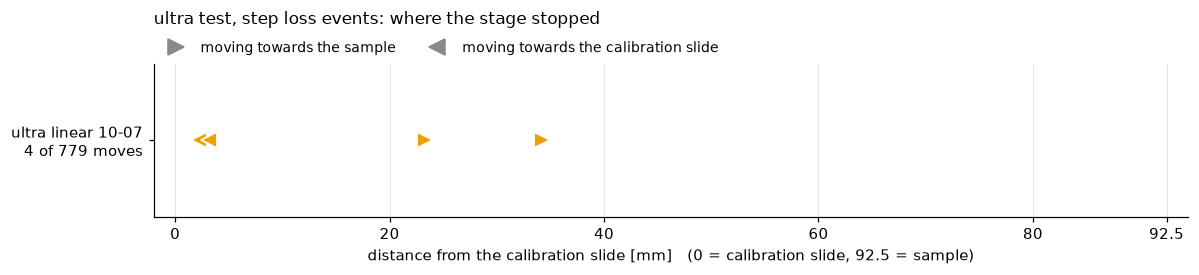

In [25]:
# from the CSVs of every run: where the stage stopped at the lost-step events, the number
# of full-speed moves (legs and random moves), and the travel between the two places
stopped_to_sample, stopped_to_slide, fast_moves, travel_mm = {}, {}, {}, {}
for name, run in ULTRA_RUNS.items():
    log = pd.read_csv(DATA_DIR / run["csv"], comment="#",
                      usecols=["visit", "place", "move", "rawCounts", "event", "xMoveSec", "stallRawCounts", "walkLost"])
    walk = pd.read_csv(DATA_DIR / run["walk_csv"], usecols=["visit", "move", "event"])
    mm_per_count = abs(run["um_per_count"]) / 1000
    # the count at the first arrival at each place
    count_at_slide = log.loc[log["place"] == "calibration slide", "rawCounts"].iloc[0]
    count_at_sample = log.loc[log["place"] == "sample", "rawCounts"].iloc[0]

    lost = log[log["event"].notna()]
    # the move that lost the steps: the row of the walk CSV with the event, else the leg.
    # Towards the sample = it has the sign of the first leg to the sample
    lost_random_move = walk[walk["event"].notna()].set_index("visit")["move"]
    lost_move = lost["visit"].map(lost_random_move).fillna(lost["move"])
    towards_sample = np.sign(lost_move) == np.sign(log.loc[log["place"] == "sample", "move"].iloc[0])

    stopped_mm = (lost["stallRawCounts"] - count_at_slide).abs() * mm_per_count
    stopped_to_sample[name] = stopped_mm[towards_sample]
    stopped_to_slide[name] = stopped_mm[~towards_sample]
    # the first leg to each place and the leg after a random move that lost steps are slow
    fast_moves[name] = ((log["xMoveSec"] < 15) & log["walkLost"].isna()).sum() + len(walk)
    travel_mm[name] = abs(count_at_sample - count_at_slide) * mm_per_count
travel = max(travel_mm.values())

fig, ax = plt.subplots(figsize=(11, 1.8 + 0.8 * len(ULTRA_RUNS)))
tick_labels = []
for row, (name, run) in enumerate(ULTRA_RUNS.items()):
    to_sample, to_slide = stopped_to_sample[name], stopped_to_slide[name]
    ax.plot(to_sample, [row] * len(to_sample), ">", color=run["color"], ms=10, mec="white", mew=1.2)
    ax.plot(to_slide, [row] * len(to_slide), "<", color=run["color"], ms=10, mec="white", mew=1.2)
    lost_moves = len(to_sample) + len(to_slide)
    if lost_moves == 0:
        ax.text(travel / 2, row, f"no step loss events in {fast_moves[name]} moves", ha="center", va="center",
                color=COLOR["ink"], fontsize=10)
    tick_labels.append(f"{name}\n{lost_moves} of {fast_moves[name]} moves")
# the legend entries are grey: the colour of a marker is the run
ax.plot([], [], ">", color=COLOR["zone"], ms=10, label="moving towards the sample")
ax.plot([], [], "<", color=COLOR["zone"], ms=10, label="moving towards the calibration slide")

ax.set_title("ultra test, step loss events: where the stage stopped", pad=26)   # pad = room for the legend
ax.set_yticks(range(len(ULTRA_RUNS)), tick_labels)
ax.set_ylim(len(ULTRA_RUNS) - 0.5, -0.5)
ax.set_xlim(-2, travel + 2)
ax.set_xticks([0, 20, 40, 60, 80, travel], ["0", "20", "40", "60", "80", f"{travel:.1f}"])
ax.set_xlabel(f"distance from the calibration slide [mm]   (0 = calibration slide, {travel:.1f} = sample)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "7_7_lost_steps_where.png")
plt.show()